# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

### Import Libraries

In [18]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.6
seaborn version: 0.13.2


### **1.1** Load the dataset

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [27]:
# Try loading one file
# df = pd.read_parquet('2023-1.parquet')
# df.info()
df2023_1 = pd.read_parquet(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-1.parquet") # loading the first file
df2023_1.info

<bound method DataFrame.info of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               2  2023-01-01 00:32:10   2023-01-01 00:40:36              1.0   
1               2  2023-01-01 00:55:08   2023-01-01 01:01:27              1.0   
2               2  2023-01-01 00:25:04   2023-01-01 00:37:49              1.0   
3               1  2023-01-01 00:03:48   2023-01-01 00:13:25              0.0   
4               2  2023-01-01 00:10:29   2023-01-01 00:21:19              1.0   
...           ...                  ...                   ...              ...   
3066761         2  2023-01-31 23:58:34   2023-02-01 00:12:33              NaN   
3066762         2  2023-01-31 23:31:09   2023-01-31 23:50:36              NaN   
3066763         2  2023-01-31 23:01:05   2023-01-31 23:25:36              NaN   
3066764         2  2023-01-31 23:40:00   2023-01-31 23:53:00              NaN   
3066765         2  2023-01-31 23:07:32   2023-01-31 23:21:56              NaN

In [29]:
df2023_1.head() # to find the top 5 rows

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [31]:
df2023_1.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3.041714e+06,3041714,3041714,2.970028e+06,3.041714e+06,2.970028e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,3.041714e+06,2.970028e+06,2.970028e+06
mean,1.727994e+00,2023-01-17 00:25:41.237371,2023-01-17 00:41:23.730543,1.362847e+00,3.855076e+00,1.500250e+00,1.664277e+02,1.644445e+02,1.176704e+00,1.867674e+01,1.558292e+00,4.963051e-01,3.394887e+00,5.263212e-01,9.983624e-01,2.744160e+01,2.309870e+00,1.098142e-01
min,1.000000e+00,2008-12-31 23:01:42,2009-01-01 14:29:11,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.250000e+00,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,2023-01-09 16:26:13,2023-01-09 16:41:19.250000,1.000000e+00,1.070000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.548000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-01-17 08:45:54,2023-01-17 09:01:55.500000,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.750000e+00,0.000000e+00,1.000000e+00,2.016000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-01-24 16:28:13.750000,2023-01-24 16:44:41,1.000000e+00,3.340000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.200000e+00,0.000000e+00,1.000000e+00,2.890000e+01,2.500000e+00,0.000000e+00
max,2.000000e+00,2023-02-01 00:56:53,2023-02-02 09:28:47,9.000000e+00,2.589281e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.160100e+03,1.250000e+01,5.316000e+01,3.808000e+02,1.969900e+02,1.000000e+00,1.169400e+03,2.500000e+00,1.250000e+00
std,4.449931e-01,NaN,NaN,8.974244e-01,2.506002e+02,6.501645e+00,6.424514e+01,6.993147e+01,4.879234e-01,1.740004e+01,1.778291e+00,5.347396e-02,3.824425e+00,2.015350e+00,3.712896e-02,2.163570e+01,6.630708e-01,3.539063e-01


In [40]:
df2023_1.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [47]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [49]:
# from google.colab import drive
# drive.mount('/content/drive')

In [51]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(r'C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df_final = pd.DataFrame()

# initialise an empty dataframe
sampled_data = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        print(file_path)
        df=pd.read_parquet(file_path)
        # Reading the current file
        df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
        df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
        dates = sorted(df["pickup_date"].unique())
        for d in dates:
            df_d = df[df["pickup_date"] == d]
            hours = sorted(df_d["pickup_hour"].unique())  # only hours present
            for hr in hours:
                df_dh = df_d[df_d["pickup_hour"] == hr]
                if df_dh.shape[0] == 0:
                    continue
            
                sampled = df_dh.sample(frac=0.05, random_state=42)
                sampled_data = pd.concat([sampled_data, sampled])


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        #df = # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
sampled_data.to_csv('sampled_nyc_taxi_data.csv', index=False)


C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-1.parquet
C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-10.parquet
C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-11.parquet
C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-12.parquet
C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-2.parquet
C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\2023-3.parquet
C:\Users\shank\anaconda_projects\Upgr

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [57]:
# Store the df in csv/parquet
# df.to_parquet('')
df2023 = pd.read_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\sampled_nyc_taxi_data.csv") # loading the first file
df2023.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count            64874
trip_distance                  0
RatecodeID                 64874
store_and_fwd_flag         64874
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       64874
airport_fee              1747917
pickup_date                    0
pickup_hour                    0
Airport_fee               213357
dtype: int64

## **2** Data Cleaning

Now we can load the new data directly.

In [61]:
# Load the new data file
df2023 = pd.read_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data\sampled_nyc_taxi_data.csv") # loading the first file
df2023.isnull().sum()


VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count            64874
trip_distance                  0
RatecodeID                 64874
store_and_fwd_flag         64874
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       64874
airport_fee              1747917
pickup_date                    0
pickup_hour                    0
Airport_fee               213357
dtype: int64

In [62]:
df2023.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


In [65]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  airport_fee            float64
 19  pickup_date            object 
 20  pickup_hour            int64  
 21  Airport_fee            float64
dtypes: float64(13), in

#### **2.1** Fixing Columns

Fix/drop any columns as you seem necessary in the below sections

**2.1.1**
Fix the index and drop unnecessary columns

In [70]:
# Fix the index and drop any columns that are not needed
df2023.head()
df2023.reset_index(drop=True, inplace=True)
print("Dropping Columns : \033[91m store_and_fwd_flag, pickup_date, pickup_hour\033[0m. Reason : droppping store_and_fwd_flag as this column is not useful in doing the analysis")
print("Also dropping pickup_date and pickup_hour, as the purpose of these columna are done.")
df2023.drop(["store_and_fwd_flag","pickup_date"], axis=1, inplace=True) # droppping store_and_fwd_flag as this column is not useful in doing the analysis
#also dropping pickup_date as the purpose of this columns is done it seems.
print ("Above columns are dropped now")


Dropping Columns :  store_and_fwd_flag, pickup_date, pickup_hour. Reason : droppping store_and_fwd_flag as this column is not useful in doing the analysis
Also dropping pickup_date and pickup_hour, as the purpose of these columna are done.
Above columns are dropped now


In [72]:
print(df2023.columns)
df2023.info() # column store_and_fwd_flag is not coming now

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'Airport_fee'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax               

**2.1.2** There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [77]:
print("Equality Comparison between two columns 1. airport_fee and 2.Airport_fee is coming as ",(df2023['airport_fee'] == df2023['Airport_fee']).all())
print("NA comparison for both the columns ",df2023[['airport_fee', 'Airport_fee']].isna().sum())
#df[['airport_fee', 'Airport_fee']].describe()
print("airport_fee 0's count is ",(df2023['airport_fee'] == 0).sum())
print("Airport_fee 0's count is ",(df2023['Airport_fee'] == 0).sum())

df2023['airport_fee_combined'] = df2023['Airport_fee'].combine_first(df2023['airport_fee'])
print("NA for new column is ",df2023['airport_fee_combined'].isna().sum())
df2023.drop(columns=['Airport_fee', 'airport_fee'], inplace=True)
df2023.rename(columns={'airport_fee_combined': 'airport_fee'}, inplace=True)

df2023.info()

Equality Comparison between two columns 1. airport_fee and 2.Airport_fee is coming as  False
NA comparison for both the columns  airport_fee    1747917
Airport_fee     213357
dtype: int64
airport_fee 0's count is  135529
Airport_fee 0's count is  1535035
NA for new column is  64874
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  

# Combine the two airport fee columns
sum_airport_fee_1st_column = df2023["airport_fee"].sum()
sum_Airport_fee_2nd_column = df2023["Airport_fee"].sum()
print('Sum of the column airport_fee is' , sum_airport_fee_1st_column)
print('Sum of the column Airport_fee is' , sum_Airport_fee_2nd_column)
print('Total sum of both the columns is' , (sum_Airport_fee_2nd_column + sum_airport_fee_1st_column))
df2023["airport_fee"] = df2023["airport_fee"].fillna(df2023["Airport_fee"])
print("Total sum of both the coumns after putting in a single column airport_fee is ", df2023["airport_fee"].sum())
## now we are sure that no data is missed as sum is proper for the single column and we can drop the Airport_fee column
df2023.drop(columns=["Airport_fee"], inplace=True)
print(df2023.columns)

**2.1.3** Fix columns with negative (monetary) values

In [83]:
# check where values of fare amount are negative
# Filter rows where fare_amount is negative
neg_fares = df2023[df2023["fare_amount"] < 0]
print(neg_fares) # it gives 0 rows so no negative fare_amount is present
df2023.info()

Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, pickup_hour, airport_fee]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           fl

Did you notice something different in the `RatecodeID` column for above records?

In [86]:
# Analyse RatecodeID for the negative fare amounts

count_RateCodeID = df2023["RatecodeID"].value_counts(dropna=False)
#print(neg_RateCodeID) # it gives 0 rows so no negative fare_amount is present
print(count_RateCodeID)
print("\033[94mTHERE IS NO NEGATIVE VALUES IN RatecodeID\033[0m")

RatecodeID
1.0     1729259
2.0       71670
NaN       64874
99.0      10472
5.0       10275
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64
THERE IS NO NEGATIVE VALUES IN RatecodeID


In [88]:
# Find which columns have negative values
print(df2023.select_dtypes(include='number').lt(0).any())
neg_cols = df2023.select_dtypes(include='number').columns[df2023.select_dtypes(include='number').lt(0).any()]
print(neg_cols)

VendorID                 False
passenger_count          False
trip_distance            False
RatecodeID               False
PULocationID             False
DOLocationID             False
payment_type             False
fare_amount              False
extra                     True
mta_tax                   True
tip_amount               False
tolls_amount             False
improvement_surcharge     True
total_amount              True
congestion_surcharge      True
pickup_hour              False
airport_fee               True
dtype: bool
Index(['extra', 'mta_tax', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [90]:
# no of rows where "extra" is negative
df2023_ex = df2023[df2023["extra"]<0]
print('extra :', len(df2023_ex))

# no of rows where "mta_tax" is negative
df2023_mt = df2023[df2023["mta_tax"]<0]
print('mta_tax : ', len(df2023_mt))

# no of rows where "improvement_surcharge" is negative
df2023_is = df2023[df2023["improvement_surcharge"]<0]
print("improvement_surcharge : ",len(df2023_is))

# no of rows where "total_amount" is negative
df2023_ta = df2023[df2023["total_amount"]<0]
print('total_amount : ',len(df2023_ta))

# no of rows where "congestion_surcharge" is negative
df2023_cs = df2023[df2023["congestion_surcharge"]<0]
print('congestion_surcharge : ',len(df2023_cs))

# no of rows where "airport_fee" is negative
df2023_af = df2023[df2023["airport_fee"]<0]
print('airport_fee : ',len(df2023_af))


extra : 3
mta_tax :  73
improvement_surcharge :  78
total_amount :  78
congestion_surcharge :  0
airport_fee :  15


In [92]:
# removing the data where "total_amount" is less than 0 as this is the data if we remove most of the negative values will get remove from the data frame
df2023_tam = df2023["total_amount"]<0
df2023 = df2023[~df2023_tam]
df2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896322 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
dtypes: float64(12), int64(5), object(2)
memory usage: 289.4+ MB


In [94]:
# no of rows where "extra" is negative
print("AFTER REMOVING THE TOTAL_AMOUNT COLUMN NEGATIVE VALUES IT MAKES THE DATA FREE OF NEGATIVE VALUES EXCEPT 1 COLUMN THAT WILL BE DEALT LATER")

df2023_ex = df2023[df2023["extra"]<0]
print('extra :', len(df2023_ex))

# no of rows where "mta_tax" is negative
df2023_mt = df2023[df2023["mta_tax"]<0]
print('mta_tax : ', len(df2023_mt))

# no of rows where "improvement_surcharge" is negative
df2023_is = df2023[df2023["improvement_surcharge"]<0]
print("improvement_surcharge : ",len(df2023_is))

# no of rows where "total_amount" is negative
df2023_ta = df2023[df2023["total_amount"]<0]
print('total_amount : ',len(df2023_ta))

# no of rows where "congestion_surcharge" is negative
df2023_cs = df2023[df2023["congestion_surcharge"]<0]
print('congestion_surcharge : ',len(df2023_cs))

# no of rows where "airport_fee" is negative
df2023_af = df2023[df2023["airport_fee"]<0]
print('airport_fee : ',len(df2023_af))

AFTER REMOVING THE TOTAL_AMOUNT COLUMN NEGATIVE VALUES IT MAKES THE DATA FREE OF NEGATIVE VALUES EXCEPT 1 COLUMN THAT WILL BE DEALT LATER
extra : 1
mta_tax :  0
improvement_surcharge :  0
total_amount :  0
congestion_surcharge :  0
airport_fee :  0


In [96]:
# removing the data where "extra" is less than 0 from the data frame

df2023_extra = df2023["extra"]<0
df2023 = df2023[~df2023_extra]
df2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896321 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
dtypes: float64(12), int64(5), object(2)
memory usage: 289.4+ MB


In [98]:
# no of rows where "extra" is negative
print("AFTER REMOVING THE EXTRA COLUMN NEGATIVE VALUES IT MAKES THE DATA FREE OF NEGATIVE VALUES EXCEPT 1 COLUMN THAT WILL BE DEALT LATER")

df2023_ex = df2023[df2023["extra"]<0]
print('extra :', len(df2023_ex))

# no of rows where "mta_tax" is negative
df2023_mt = df2023[df2023["mta_tax"]<0]
print('mta_tax : ', len(df2023_mt))

# no of rows where "improvement_surcharge" is negative
df2023_is = df2023[df2023["improvement_surcharge"]<0]
print("improvement_surcharge : ",len(df2023_is))

# no of rows where "total_amount" is negative
df2023_ta = df2023[df2023["total_amount"]<0]
print('total_amount : ',len(df2023_ta))

# no of rows where "congestion_surcharge" is negative
df2023_cs = df2023[df2023["congestion_surcharge"]<0]
print('congestion_surcharge : ',len(df2023_cs))

# no of rows where "airport_fee" is negative
df2023_af = df2023[df2023["airport_fee"]<0]
print('airport_fee : ',len(df2023_af))

AFTER REMOVING THE EXTRA COLUMN NEGATIVE VALUES IT MAKES THE DATA FREE OF NEGATIVE VALUES EXCEPT 1 COLUMN THAT WILL BE DEALT LATER
extra : 0
mta_tax :  0
improvement_surcharge :  0
total_amount :  0
congestion_surcharge :  0
airport_fee :  0


In [100]:
# Find which columns have negative values
print( "AFTER THE FULL CLEANUP OF NEGATIVE VALUES WE WILL SEE WHICH ALL COLUMNS STILL HAS NEGTIVE VALUES IN THE DATA FRAME")
print(df2023.select_dtypes(include='number').lt(0).any())
neg_cols = df2023.select_dtypes(include='number').columns[df2023.select_dtypes(include='number').lt(0).any()]
print(neg_cols)

AFTER THE FULL CLEANUP OF NEGATIVE VALUES WE WILL SEE WHICH ALL COLUMNS STILL HAS NEGTIVE VALUES IN THE DATA FRAME
VendorID                 False
passenger_count          False
trip_distance            False
RatecodeID               False
PULocationID             False
DOLocationID             False
payment_type             False
fare_amount              False
extra                    False
mta_tax                  False
tip_amount               False
tolls_amount             False
improvement_surcharge    False
total_amount             False
congestion_surcharge     False
pickup_hour              False
airport_fee              False
dtype: bool
Index([], dtype='object')


### **2.2** Handling Missing Values

**2.2.1** Find the proportion of missing values in each column




In [106]:
# Find the proportion of missing values in each column

missingValue_proportion = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion)


VendorID                 0.00000
tpep_pickup_datetime     0.00000
tpep_dropoff_datetime    0.00000
passenger_count          0.03421
trip_distance            0.00000
RatecodeID               0.03421
PULocationID             0.00000
DOLocationID             0.00000
payment_type             0.00000
fare_amount              0.00000
extra                    0.00000
mta_tax                  0.00000
tip_amount               0.00000
tolls_amount             0.00000
improvement_surcharge    0.00000
total_amount             0.00000
congestion_surcharge     0.03421
pickup_hour              0.00000
airport_fee              0.03421
dtype: float64


In [108]:
pasngr_count_mode = df2023['passenger_count'].mode()[0]
print(pasngr_count_mode)
df2023.fillna({'passenger_count': pasngr_count_mode}, inplace=True)

1.0


In [110]:
# Find the proportion of missing values in each column

missingValue_proportion1 = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion1)


VendorID                 0.00000
tpep_pickup_datetime     0.00000
tpep_dropoff_datetime    0.00000
passenger_count          0.00000
trip_distance            0.00000
RatecodeID               0.03421
PULocationID             0.00000
DOLocationID             0.00000
payment_type             0.00000
fare_amount              0.00000
extra                    0.00000
mta_tax                  0.00000
tip_amount               0.00000
tolls_amount             0.00000
improvement_surcharge    0.00000
total_amount             0.00000
congestion_surcharge     0.03421
pickup_hour              0.00000
airport_fee              0.03421
dtype: float64


**2.2.2** Handling missing values in `passenger_count`

In [113]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'


Did you find zeroes in passenger_count? Handle these.

**2.2.3** Handle missing values in `RatecodeID`

In [116]:
# Fix missing values in 'RatecodeID'
missingValue_proportion = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion)
RatecodeID_mode = df2023['RatecodeID'].mode()[0]
print(RatecodeID_mode)

VendorID                 0.00000
tpep_pickup_datetime     0.00000
tpep_dropoff_datetime    0.00000
passenger_count          0.00000
trip_distance            0.00000
RatecodeID               0.03421
PULocationID             0.00000
DOLocationID             0.00000
payment_type             0.00000
fare_amount              0.00000
extra                    0.00000
mta_tax                  0.00000
tip_amount               0.00000
tolls_amount             0.00000
improvement_surcharge    0.00000
total_amount             0.00000
congestion_surcharge     0.03421
pickup_hour              0.00000
airport_fee              0.03421
dtype: float64
1.0


In [118]:
df2023.fillna({'RatecodeID': RatecodeID_mode}, inplace=True)

In [120]:
#dropping ratecodeID where value is 99
df_ratecode99 = df2023[df2023["RatecodeID"]==99.0].index

# Drop rows by index
df2023.drop(df_ratecode99, inplace=True)

In [122]:
missingValue_proportion1 = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion1)

VendorID                 0.0000
tpep_pickup_datetime     0.0000
tpep_dropoff_datetime    0.0000
passenger_count          0.0000
trip_distance            0.0000
RatecodeID               0.0000
PULocationID             0.0000
DOLocationID             0.0000
payment_type             0.0000
fare_amount              0.0000
extra                    0.0000
mta_tax                  0.0000
tip_amount               0.0000
tolls_amount             0.0000
improvement_surcharge    0.0000
total_amount             0.0000
congestion_surcharge     0.0344
pickup_hour              0.0000
airport_fee              0.0344
dtype: float64


**2.2.4**  Impute NaN in `congestion_surcharge`

In [125]:
# handle null values in congestion_surcharge
df2023["congestion_surcharge"].value_counts()
#df2023["congestion_surcharge"].isnull().sum()
cngst_surch_mode = df2023['congestion_surcharge'].mode()[0]
print(cngst_surch_mode)

2.5


In [127]:
missingValue_proportion1 = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion1)

VendorID                 0.0000
tpep_pickup_datetime     0.0000
tpep_dropoff_datetime    0.0000
passenger_count          0.0000
trip_distance            0.0000
RatecodeID               0.0000
PULocationID             0.0000
DOLocationID             0.0000
payment_type             0.0000
fare_amount              0.0000
extra                    0.0000
mta_tax                  0.0000
tip_amount               0.0000
tolls_amount             0.0000
improvement_surcharge    0.0000
total_amount             0.0000
congestion_surcharge     0.0344
pickup_hour              0.0000
airport_fee              0.0344
dtype: float64


In [129]:
df2023.fillna({'congestion_surcharge': cngst_surch_mode}, inplace=True)

In [131]:
missingValue_proportion1 = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion1)

VendorID                 0.0000
tpep_pickup_datetime     0.0000
tpep_dropoff_datetime    0.0000
passenger_count          0.0000
trip_distance            0.0000
RatecodeID               0.0000
PULocationID             0.0000
DOLocationID             0.0000
payment_type             0.0000
fare_amount              0.0000
extra                    0.0000
mta_tax                  0.0000
tip_amount               0.0000
tolls_amount             0.0000
improvement_surcharge    0.0000
total_amount             0.0000
congestion_surcharge     0.0000
pickup_hour              0.0000
airport_fee              0.0344
dtype: float64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [134]:
# Handle any remaining missing values

missingValue_proportion1 = df2023.isnull().sum() / len(df2023)
print(missingValue_proportion1)

VendorID                 0.0000
tpep_pickup_datetime     0.0000
tpep_dropoff_datetime    0.0000
passenger_count          0.0000
trip_distance            0.0000
RatecodeID               0.0000
PULocationID             0.0000
DOLocationID             0.0000
payment_type             0.0000
fare_amount              0.0000
extra                    0.0000
mta_tax                  0.0000
tip_amount               0.0000
tolls_amount             0.0000
improvement_surcharge    0.0000
total_amount             0.0000
congestion_surcharge     0.0000
pickup_hour              0.0000
airport_fee              0.0344
dtype: float64


In [136]:
df2023["airport_fee"].value_counts()

airport_fee
0.00    1660028
1.75     121123
1.25      39823
1.00          1
Name: count, dtype: int64

In [138]:
df2023["airport_fee"].isnull().sum()

64874

In [140]:
#df2023.to_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataAirport_fee.csv")


import geopandas as gpd

gdf = gpd.read_file(r"C:\Users\shank\anaconda_projects\Upgrad\Upgrad Platform Materials - Course\Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\taxi_zones.shp")

print(gdf.head())
print(gdf.columns)


import shapefile

# Read shapefile
sf = shapefile.Reader(r"C:\Users\shank\anaconda_projects\Upgrad\Upgrad Platform Materials - Course\Data Analysis and Exploration\Project\Datasets and Dictionary\taxi_zones\taxi_zones.shp1")

# Records (attribute table)
records = sf.records()
print(records[:5])

# Shapes (geometry)
shapes = sf.shapes()
print(shapes[0].points)

### **2.3** Handling Outliers

Before we start fixing outliers, let's perform outlier analysis.

In [146]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns



**2.3.1**  
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

In [150]:
#Entries where trip_distance is nearly 0 and fare_amount is more than 300
pd.set_option("display.float_format", "{:.2f}".format)
df2023["trip_distance"].describe()
((df2023["trip_distance"] < 0.01) & (df2023["fare_amount"] > 300.00)).value_counts()

False    1885817
True          32
Name: count, dtype: int64

In [152]:
df2023 = df2023[~((df2023['trip_distance'] < 0.01) & (df2023['fare_amount'] > 300))]
df2023.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1885817 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
dtypes: float64(12), int64(5), object(2)
memory usage: 287.8+ MB


In [154]:
# Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)

dfIndexToDrop=df2023[
    (df2023['trip_distance'] == 0) & 
    (df2023['fare_amount'] == 0) & 
    (df2023['PULocationID'] != df2023['DOLocationID'])
].index
df2023.drop(dfIndexToDrop, inplace=True)
df2023.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1885763 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
dtypes: float64(12), int64(5), object(2)
memory usage: 287.7+ MB


How will you fix each of these values? Which ones will you drop and which ones will you replace?

In [157]:
#Entries where trip_distance is more than 250 miles.
count=len(df2023[df2023['trip_distance'] >=250.00])
print ("Entries where trip_distance is more than 250 miles.", count)
df2023=df2023[df2023['trip_distance'] <250.00]
df2023.shape

Entries where trip_distance is more than 250 miles. 43


(1885720, 19)

First, let us remove 7+ passenger counts as there are very less instances.

In [160]:
#Entries where payment_type is 0 
print(df2023['payment_type'].value_counts())
df2023=df2023[df2023['payment_type']!=0]
df2023.shape

payment_type
1    1481861
2     316343
0      64844
4      13670
3       9002
Name: count, dtype: int64


(1820876, 19)

In [162]:
#DROP AND PICK UP TIME IS SAME and trip distance is 0
print("count of DROP AND PICK UP TIME IS SAME and trip distance is 0 is ",len(df2023[(df2023['tpep_pickup_datetime']==df2023['tpep_dropoff_datetime']) & (df2023['trip_distance']==0)]))

df_drop = df2023[(df2023['tpep_pickup_datetime']==df2023['tpep_dropoff_datetime']) & (df2023['trip_distance']==0)]
df_drop.shape
df2023 = df2023.drop(df_drop.index)
df2023.shape

count of DROP AND PICK UP TIME IS SAME and trip distance is 0 is  559


(1820317, 19)

In [164]:

# deleting the trips where trip time is less then 60 seconds as withing this time trip is not possible
df2023['tpep_pickup_datetime'] = pd.to_datetime(df2023['tpep_pickup_datetime'])
df2023['tpep_dropoff_datetime'] = pd.to_datetime(df2023['tpep_dropoff_datetime'])

df2023['trip_duration_sec'] = (df2023['tpep_dropoff_datetime'] - df2023['tpep_pickup_datetime']).dt.total_seconds()

short_trips = df2023[df2023['trip_duration_sec'] <= 60]
print("Short trips count:", len(short_trips))
df2023.shape

Short trips count: 18601


(1820317, 20)

In [165]:
#handling trip duration where trip duration is less than 0 seconds
df2023['trip_duration_sec'].describe()

count   1820317.00
mean       1034.30
std        2505.32
min       -3258.00
25%         454.00
50%         749.00
75%        1222.00
max      375983.00
Name: trip_duration_sec, dtype: float64

In [167]:
(df2023['trip_duration_sec'] < 0).value_counts()

trip_duration_sec
False    1820278
True          39
Name: count, dtype: int64

In [170]:
# deleting trip duration where its in negative
df_negative_time=df2023[(df2023['trip_duration_sec'] < 0)]
print(len(df_negative_time))
df2023 = df2023.drop(df_negative_time.index)
df2023.shape
df2023['trip_duration_sec'].describe()

39


count   1820278.00
mean       1034.37
std        2505.29
min           0.00
25%         454.00
50%         749.00
75%        1222.00
max      375983.00
Name: trip_duration_sec, dtype: float64

In [172]:
df_short_trips =  df2023[(df2023['trip_distance'] == 0) & (df2023['trip_duration_sec'] >= 60)]
len(df_short_trips)

8371

In [174]:
# deleting short trips where the trip distance is 0 and trip duration is less than 60 seconds
df_short_trips =  df2023[(df2023['trip_distance'] == 0) & (df2023['trip_duration_sec'] < 60)]
len(df_short_trips)
df2023 = df2023.drop(df_short_trips.index)
df2023.shape

(1807437, 20)

In [176]:
df_short_trips =  df2023[(df2023['trip_distance'] == 0) & (df2023['trip_duration_sec'] < 60)]
df_short_trips.shape
# now no data should be coming for trip distance 0 and trip duration < 60 seconds

(0, 20)

In [178]:
df2023.shape

(1807437, 20)

In [180]:
# Deleteing Entries where `trip_distance` and `fare_amount` are 0 

# Count rows to be deleted
print("Number of rows where `trip_distance` and `fare_amount` are 0:", 
      len(df2023[(df2023['trip_distance'] == 0) & (df2023['fare_amount'] == 0)]))

# Get index of rows to drop
dfIndexToDrop = df2023[
    (df2023['trip_distance'] == 0) & 
    (df2023['fare_amount'] == 0)
].index

# Drop rows by index
df2023.drop(dfIndexToDrop, inplace=True)

# Confirm deletion
df2023.info()


Number of rows where `trip_distance` and `fare_amount` are 0: 49
<class 'pandas.core.frame.DataFrame'>
Index: 1807388 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  picku

In [182]:
# remove passenger_count > 6
print("Where the passenger count is greater than 6 we are deleting those rows and its length is ", len(df2023[df2023["passenger_count"]>6]))

# Get index of rows to drop
dfIndexToDrop = df2023[
    (df2023['passenger_count'] > 6)
].index

# Drop rows by index
df2023.drop(dfIndexToDrop, inplace=True)

# Confirm deletion
df2023.shape

Where the passenger count is greater than 6 we are deleting those rows and its length is  11


(1807377, 20)

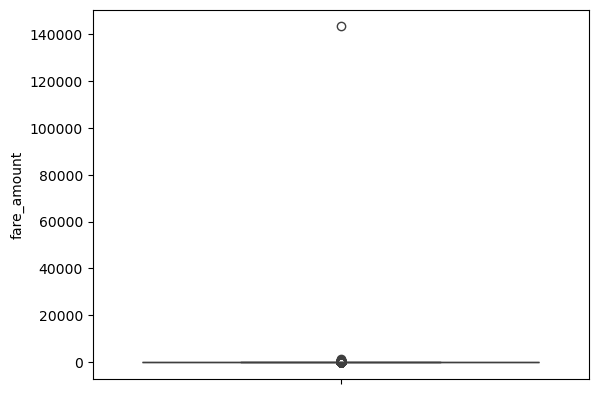

In [184]:
# Continue with outlier handling

sns.boxplot(df2023.fare_amount)
plt.show()

In [185]:
# Continue with outlier handling

len(df2023[df2023["fare_amount"]>2000])
df2023.shape

(1807377, 20)

In [186]:
# deleting the row where fare amount is greater than 2000
df_fare_amount = df2023[df2023["fare_amount"]>2000].index

# Drop rows by index
df2023.drop(df_fare_amount, inplace=True)

# Confirm deletion
df2023.shape

(1807376, 20)

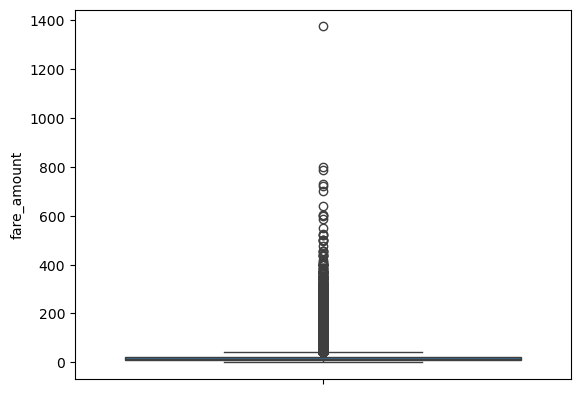

In [187]:
# Continue with outlier handling

sns.boxplot(df2023.fare_amount)
plt.show()

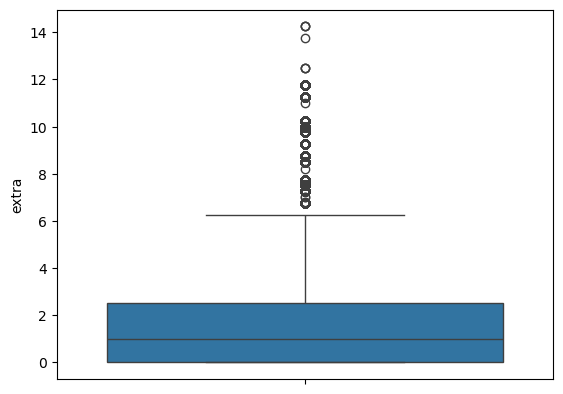

In [188]:
# Continue with outlier handling

sns.boxplot(df2023.extra)
plt.show()
#this column looks fine 

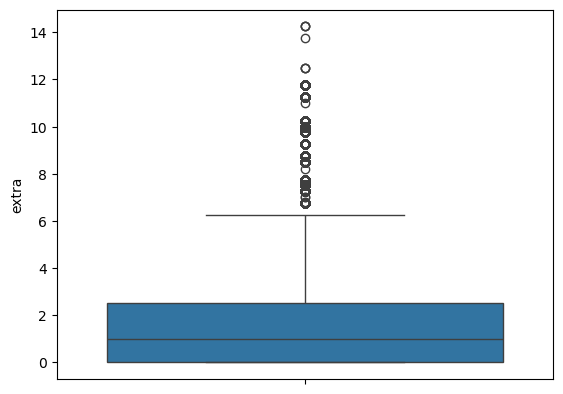

In [189]:
# Continue with outlier handling

sns.boxplot(df2023.extra)
plt.show()
#this column looks fine 

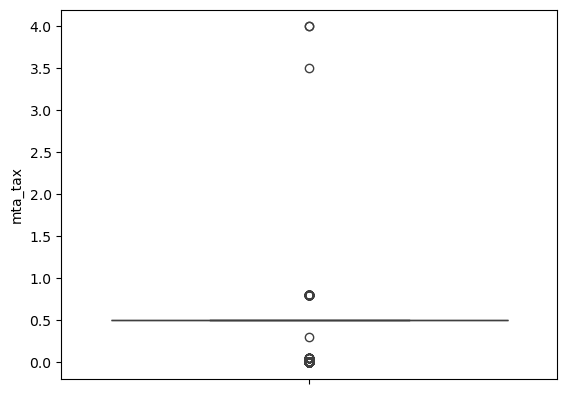

In [190]:
# Continue with outlier handling

sns.boxplot(df2023.mta_tax)
plt.show()
#this column looks fine 

In [198]:
# Continue with outlier handling on mta_tax
df2023["mta_tax"].value_counts()
# Ad the tax can be levied at any rate so we are keeping this column as it is

mta_tax
0.50    1795113
0.00      12193
0.80         49
0.05         17
4.00          2
0.30          1
3.50          1
Name: count, dtype: int64

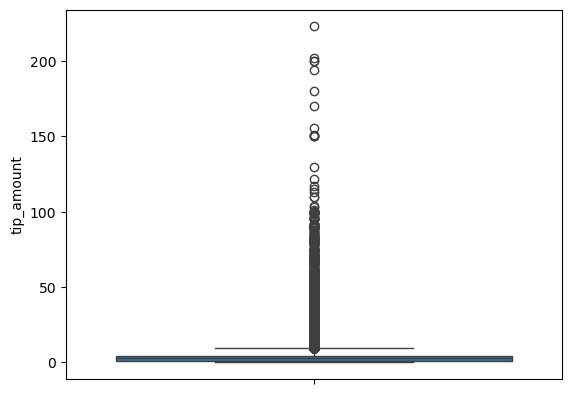

In [200]:
# Continue with outlier handling

sns.boxplot(df2023.tip_amount)
plt.show()
#this column looks fine as the tip given by a person can be any amount

In [201]:
#df2023.to_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataOutliers.csv")

In [202]:
df2023.shape

(1807376, 20)

In [203]:
# Continue with outlier handling
# Deleting the records where tip amount is more than 50 % of the total amount and tip amount is greater than 100
df_tamtprct = df2023[((df2023["tip_amount"])/df2023["total_amount"])>.5]
df_tamtprct = df_tamtprct[df_tamtprct["tip_amount"]>100].index

# Drop rows by index
df2023.drop(df_tamtprct, inplace=True)

# Confirm deletion
df2023.shape

(1807356, 20)

In [208]:
#Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. 

#df2023.to_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataOutliers.csv")

# Identify rows where payment_type is not 1 and tip_amount > 0
mask = (df2023["payment_type"] != 1) & (df2023["tip_amount"] > 0)

# Subtract tip_amount from total_amount for those rows
df2023.loc[mask, "total_amount"] = df2023.loc[mask, "total_amount"] - df2023.loc[mask, "tip_amount"]

# Set tip_amount to 0 for those rows
df2023.loc[mask, "tip_amount"] = 0

print("Remaining rows with payment_type != 1 and tip_amount > 0:", 
      df2023[(df2023["payment_type"] != 1) & (df2023["tip_amount"] > 0)].shape[0])


Remaining rows with payment_type != 1 and tip_amount > 0: 0


In [210]:
df2023.to_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataOutliers_1.csv", index=False)


In [211]:
df2023 = pd.read_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataOutliers_1.csv")

In [212]:
df2023.shape

(1807356, 20)

In [213]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           int64  
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
 19  trip_duration_sec      float64
dtypes: float64(13), int64(5), object(2)
memory usage: 275.8+ MB


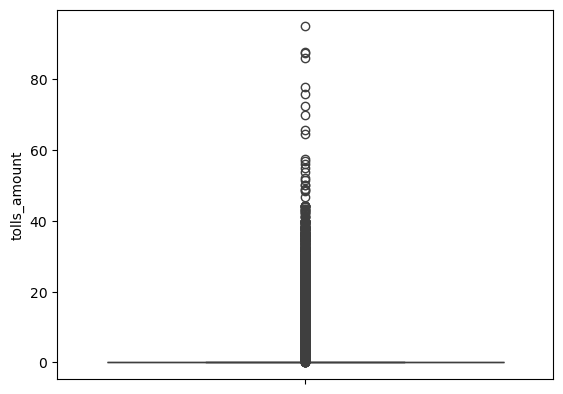

In [214]:
# Continue with outlier handling

sns.boxplot(df2023.tolls_amount)
plt.show()
#this column looks fine as the toll given by a person can be any amount based on the tolls and dont have a drastic difference

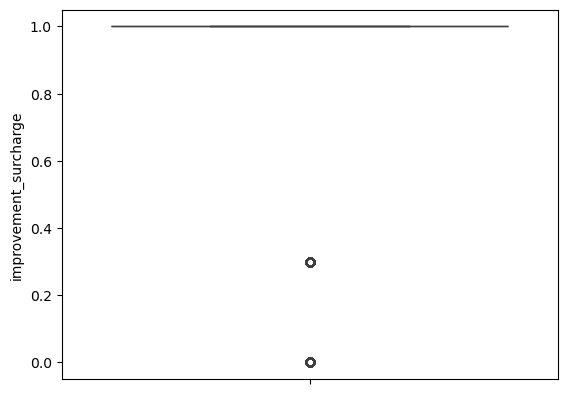

In [215]:
# Continue with outlier handling

sns.boxplot(df2023.improvement_surcharge)
plt.show()


In [216]:
# Continue with outlier handling on improvement_surcharge
df2023["improvement_surcharge"].value_counts()

improvement_surcharge
1.00    1806197
0.30        798
0.00        361
Name: count, dtype: int64

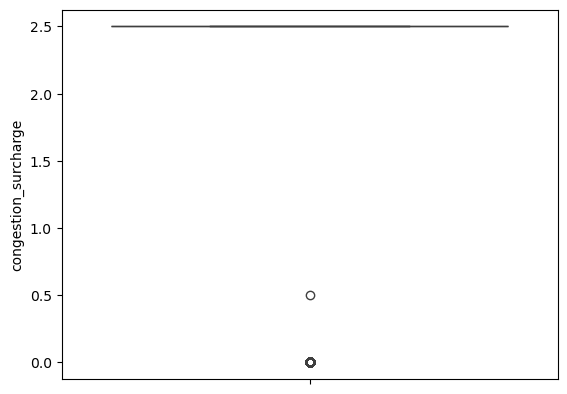

In [217]:
# Continue with outlier handling

sns.boxplot(df2023.congestion_surcharge)
plt.show()

In [218]:
# Continue with outlier handling on improvement_surcharge
df2023["congestion_surcharge"].value_counts()
#In the box plot its seen that the value lies between 0 to 2.5 so no outliers are there. 0.5 is a valid value

congestion_surcharge
2.50    1685035
0.00     122320
0.50          1
Name: count, dtype: int64

# imp surcharge needs some more discussion

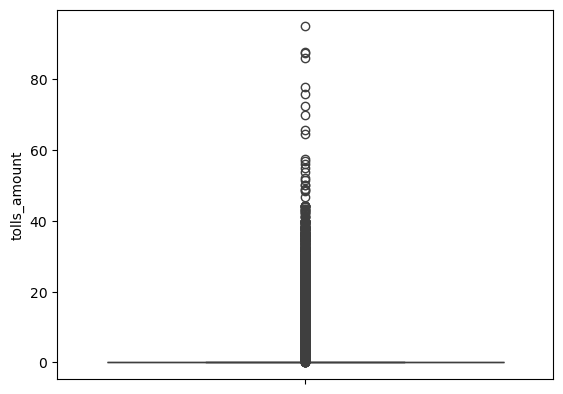

In [221]:
# Continue with outlier handling

sns.boxplot(df2023.tolls_amount)
plt.show()
#this column looks fine as the toll given by a person can be any amount based on the tolls and dont have a drastic difference

In [223]:
# Do any columns need standardising?

A numeric code signifying how the passenger paid for the trip.  
1= Credit card 
2= Cash 
3= No charge 
4= Dispute 
5= Unknown 
6= Voided trip

In [225]:
# standardising for payment_type
df2023["payment_type"].value_counts()

payment_type
1    1475778
2     311797
4      12526
3       7255
Name: count, dtype: int64

In [226]:
df2023['payment_type'] = df2023['payment_type'].map({
    1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'
})

In [227]:
df2023["payment_type"].value_counts()

payment_type
Credit card    1475778
Cash            311797
Dispute          12526
No charge         7255
Name: count, dtype: int64

In [228]:
# standardising for VendorID
df2023["VendorID"].value_counts()
# From Data Dictionary
#1= Creative Mobile Technologies, LLC
#2= VeriFone Inc. 

VendorID
2    1338884
1     468472
Name: count, dtype: int64

In [229]:
df2023['VendorID'] = df2023['VendorID'].map({
    1: 'Creative Mobile Technologies, LLC', 2: 'VeriFone Inc.'
})

In [230]:
df2023["VendorID"].value_counts()


VendorID
VeriFone Inc.                        1338884
Creative Mobile Technologies, LLC     468472
Name: count, dtype: int64

### standardising for RateCodeID
RateCodeID
The final rate code in effect at the end of the trip. 
 
1= Standard rate 
2=JFK 
3=Newark 
4=Nassau or Westchester 
5=Negotiated fare 
6=Group ride 

In [232]:
df2023["RatecodeID"].value_counts()

RatecodeID
1.00    1722264
2.00      70174
3.00       5833
5.00       5375
4.00       3709
6.00          1
Name: count, dtype: int64

In [233]:
df2023['RatecodeID'] = df2023['RatecodeID'].map({
    1: 'Standard rate', 2: 'JFK', 3: 'Newark', 4: 'Nassau or Westchester', 5: 'Negotiated fare', 6: 'Group ride'
})

In [234]:
df2023["RatecodeID"].value_counts()

RatecodeID
Standard rate            1722264
JFK                        70174
Newark                      5833
Negotiated fare             5375
Nassau or Westchester       3709
Group ride                     1
Name: count, dtype: int64

## **3** Exploratory Data Analysis

In [262]:
df2023.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_hour',
 'airport_fee',
 'trip_duration_sec']

#### **3.1** General EDA: Finding Patterns and Trends

**3.1.1** Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical (Can be used to derive numerical features like hour, day, duration)
* `tpep_dropoff_datetime`: Numerical (Can be used to derive numerical features like hour, day, duration)
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

All the below ones are Numerical
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** Analyse the distribution of taxi pickups by hours, days of the week, and months.

Q1 (25%): 11.0
Q2 (Median): 15.0
Q3 (75%): 19.0


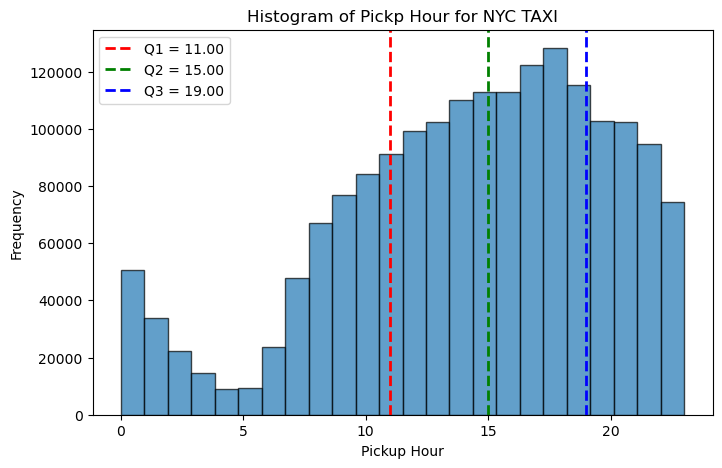

In [268]:
# Find and show the hourly trends in taxi pickups
# Calculate quartiles
q1 = df2023["pickup_hour"].quantile(0.25)
q2 = df2023["pickup_hour"].quantile(0.50)  # Median
q3 = df2023["pickup_hour"].quantile(0.75)

print("Q1 (25%):", q1)
print("Q2 (Median):", q2)
print("Q3 (75%):", q3)

plt.figure(figsize=(8,5))
plt.hist(df2023["pickup_hour"], bins=24, edgecolor="black", alpha=0.7)
plt.axvline(q1, color="red", linestyle="--", linewidth=2, label=f"Q1 = {q1:.2f}")
plt.axvline(q2, color="green", linestyle="--", linewidth=2, label=f"Q2 = {q2:.2f}")
plt.axvline(q3, color="blue", linestyle="--", linewidth=2, label=f"Q3 = {q3:.2f}")

plt.title("Histogram of Pickp Hour for NYC TAXI")
plt.xlabel("Pickup Hour")
plt.ylabel("Frequency")
plt.legend()
plt.show()



#### Conclusion with the histogram shown above is : 
1. Peak hour is 18 Hours
2. Between 15 to 19 its rush hours and traffic is more
3. 0 to 11 hours the traffic is lesser when compared to 15 to 19 hours
4. Least pickup and traffic is at 4 and 5th hour
5. Between 11 to 15 and 19-23 the traffic is moderate

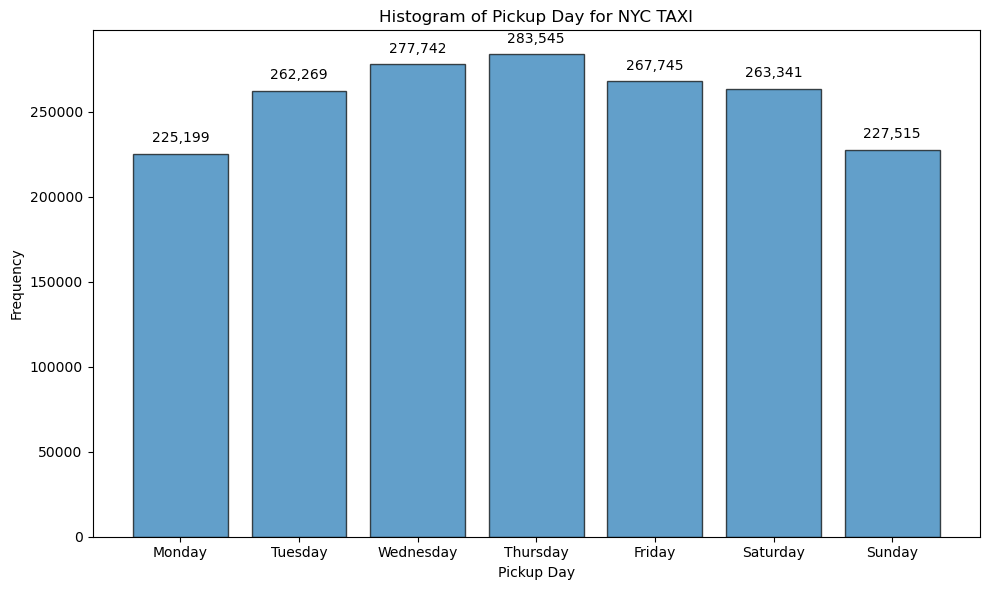

In [271]:
# Find and show the daily trends in taxi pickups (days of the week)

df2023['tpep_pickup_datetime'] = pd.to_datetime(df2023['tpep_pickup_datetime'], errors='coerce')

df2023['pickup_day_name'] = df2023['tpep_pickup_datetime'].dt.day_name()

day_counts = df2023['pickup_day_name'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(day_counts.index, day_counts.values, edgecolor='black', alpha=0.7)

# Title and labels
plt.title("Histogram of Pickup Day for NYC TAXI")
plt.xlabel("Pickup Day")
plt.ylabel("Frequency")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5000, f'{height:,}', 
             ha='center', va='bottom', fontsize=10)

# Center-align x-axis labels
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()



### Conclusion for the pickup day is as below:
1. Sunday and Moday the number of pickup is less
2. Tuesday, Friday and Saturday its moderate
3. Wednesdays and Thursdays there are more pickups

In [273]:
# Show the monthly trends in pickups

# Find and show the daily trends in taxi pickups (days of the week)

df2023['pickup_month'] = df2023['tpep_pickup_datetime'].dt.month_name()


In [274]:
df2023.head()
df2023['pickup_month'].value_counts()

pickup_month
May          166845
October      164289
March        162126
June         157111
April        156510
November     156253
December     155465
January      146739
February     139046
July         137781
August       133167
September    132024
Name: count, dtype: int64

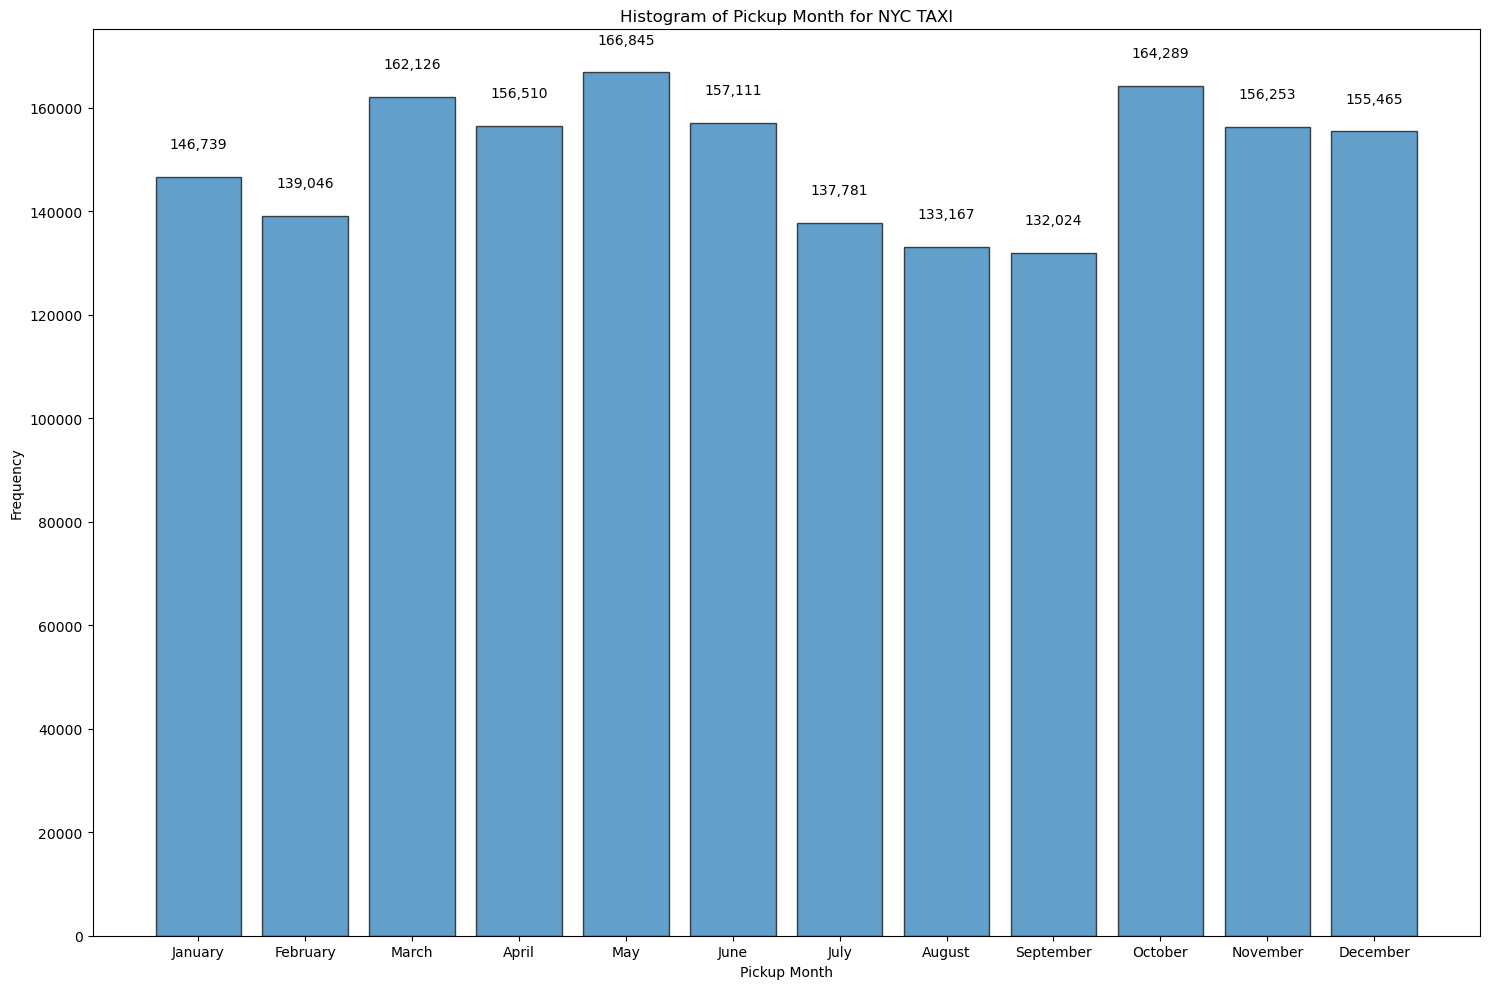

In [276]:

day_counts = df2023['pickup_month'].value_counts().reindex([
   'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
])

# Plot
plt.figure(figsize=(15,10))
bars = plt.bar(day_counts.index, day_counts.values, edgecolor='black', alpha=0.7)

# Title and labels
plt.title("Histogram of Pickup Month for NYC TAXI")
plt.xlabel("Pickup Month")
plt.ylabel("Frequency")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5000, f'{height:,}', 
             ha='center', va='bottom', fontsize=10)

# Center-align x-axis labels
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()



In [277]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee           

### Conclusion for the pickup month is as below:
1. February, July, August and September the number of pickup is less.
2. January , April, June, November and December its moderate.
3. March, May and October there are more pickups.

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [283]:
# Analyse the above parameters
has_zero_or_negative = (df2023['fare_amount'] < 0).any()
print(has_zero_or_negative)
len(df2023[df2023['fare_amount']==0])

False


243

In [284]:
has_zero_or_negative = (df2023['tip_amount'] < 0).any()
print(has_zero_or_negative)
len(df2023[df2023['tip_amount']==0])

False


390781

In [288]:
has_zero_or_negative = (df2023['total_amount'] < 0).any()
print(has_zero_or_negative)
len(df2023[df2023['total_amount']==0])

False


63

In [290]:
has_zero_or_negative = (df2023['trip_distance'] < 0).any()
print(has_zero_or_negative)
len(df2023[df2023['trip_distance']==0])

False


8320

In [293]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee           

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [299]:
# Create a df with non zero entries for the selected parameters.

df_nonzero = df2023[
    (df2023['fare_amount'] != 0) &
    (df2023['total_amount'] != 0) &
    (df2023['trip_distance'] != 0)
].copy()


In [300]:
df_nonzero.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1798793 entries, 0 to 1807355
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee            floa

**3.1.4** Analyse the monthly revenue (`total_amount`) trend

C:\Users\shank\AppData\Local\Temp\ipykernel_30032\2649932839.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_nonzero.groupby('pickup_month')['total_amount']


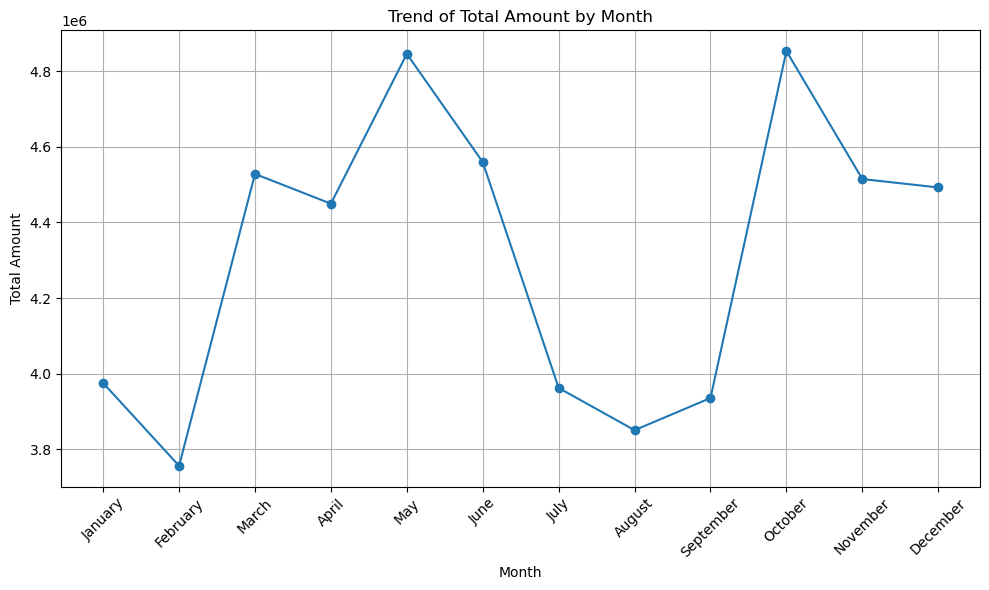

In [302]:
# Aggregate total_amount by month
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df_nonzero['pickup_month'] = pd.Categorical(
    df_nonzero['pickup_month'],
    categories=month_order,
    ordered=True
)
monthly_totals = (
    df_nonzero.groupby('pickup_month')['total_amount']
    .sum()
    .reset_index()
    .sort_values('pickup_month')
)

plt.figure(figsize=(10, 6))
plt.plot(monthly_totals['pickup_month'], monthly_totals['total_amount'], marker='o')
plt.xticks(rotation=45)
plt.title('Trend of Total Amount by Month')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.grid(True)
plt.tight_layout()
plt.show()


## Analysis is :
1. Revenue is least in February.
2. In month of May and October the revenue is high
3. There is a good growth from February to March AND September to October.
4. there is a steep decline from Maay to August.

**3.1.5** 
Show the proportion of each quarter of the year in the revenue

In [307]:
# Calculate proportion of each quarter
df2023['pickup_quarter'] = 'Q' + df2023['tpep_pickup_datetime'].dt.quarter.astype(str)


In [308]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee           

In [309]:
df2023["pickup_quarter"].value_counts()

pickup_quarter
Q2    480466
Q4    476007
Q1    447911
Q3    402972
Name: count, dtype: int64

In [310]:
quarter_revenue = (
    df2023.groupby('pickup_quarter')['total_amount']
    .sum()
    .sort_index()
)

revenue_proportion = (quarter_revenue / quarter_revenue.sum()).round(4)

In [312]:
print(df2023.groupby("pickup_quarter")['total_amount'].sum())

pickup_quarter
Q1   12316386.99
Q2   13911852.31
Q3   11803879.59
Q4   13916669.98
Name: total_amount, dtype: float64


In [313]:
summary_df = pd.DataFrame({
    'Quarter': revenue_proportion.index,
    'Revenue Proportion': revenue_proportion.round(4).values
})
print(summary_df)

  Quarter  Revenue Proportion
0      Q1                0.24
1      Q2                0.27
2      Q3                0.23
3      Q4                0.27


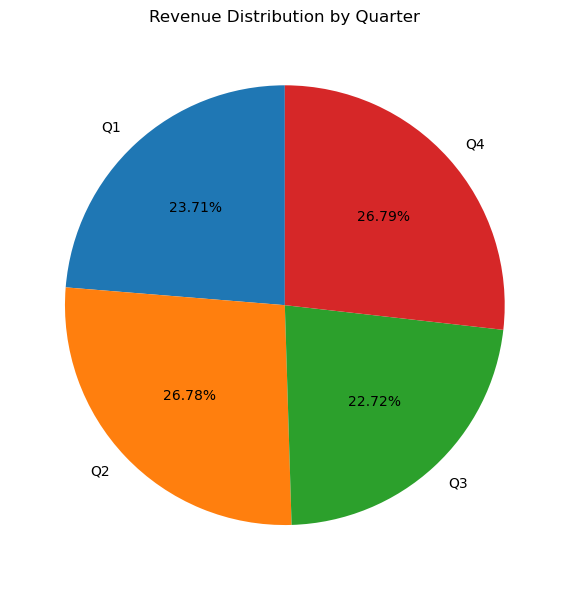

In [314]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.pie(revenue_proportion, labels=revenue_proportion.index, autopct='%1.2f%%', startangle=90)
plt.title('Revenue Distribution by Quarter')
plt.tight_layout()
plt.show()

**3.1.6** 
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [317]:
df2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee           

In [318]:
# Show how trip fare is affected by distance
df2023_1 = df2023[df2023["trip_distance"]!=0]
df2023_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1799036 entries, 0 to 1807355
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee            floa

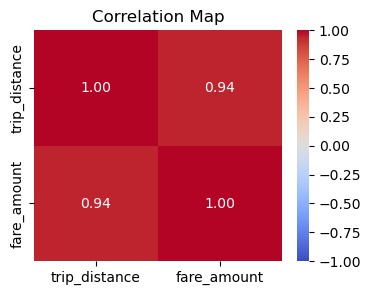

In [319]:
corr = df2023_1[['trip_distance', 'fare_amount']].corr()

# Plot heatmap of the correlation matrix
plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Map')
plt.show()

In [322]:
## Conclusion is
#The trip_distance and fare_amount are highly positively correlated. and the correlation value is 0.94

**3.1.7** 
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [325]:
df2023_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1799036 entries, 0 to 1807355
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  object        
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int64         
 18  airport_fee            floa

C:\Users\shank\AppData\Local\Temp\ipykernel_30032\992731305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2023_1['tpep_dropoff_datetime'] = pd.to_datetime(df2023_1['tpep_dropoff_datetime'], errors='coerce')
C:\Users\shank\AppData\Local\Temp\ipykernel_30032\992731305.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2023_1['trip_duration_sec'] = (df2023_1['tpep_dropoff_datetime'] - df2023_1['tpep_pickup_datetime']).dt.total_seconds()


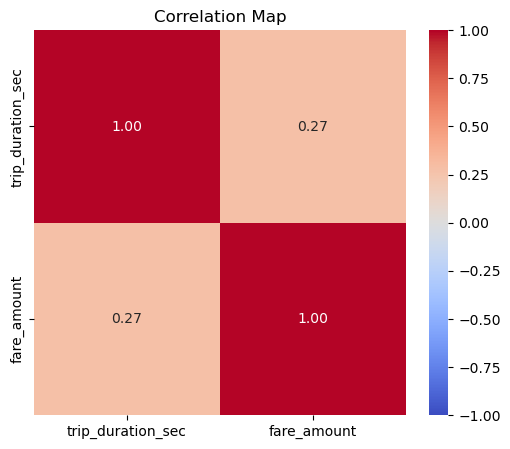

In [326]:
# Show relationship between fare and trip duration
df2023_1['tpep_dropoff_datetime'] = pd.to_datetime(df2023_1['tpep_dropoff_datetime'], errors='coerce')
df2023_1['trip_duration_sec'] = (df2023_1['tpep_dropoff_datetime'] - df2023_1['tpep_pickup_datetime']).dt.total_seconds()
corr = df2023_1[['trip_duration_sec', 'fare_amount']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Map')
plt.show()


In [328]:
# Conclusion is
# There is a weak positive correlation (r = 0.27) between trip duration and fare amount, indicating that longer trips tend to have higher fares, but the relationship is not very strong.

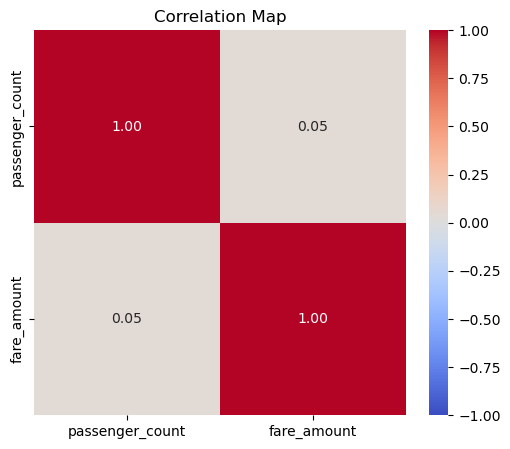

In [329]:
# Show relationship between fare and number of passengers
corr = df2023_1[['passenger_count', 'fare_amount']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Map')
plt.show()


In [332]:
# Conclusion is
# Passenger count and fare amount show a very weak positive correlation or no correlation (r = 0.05) as it tends to 0. 
# This indicates that the number of passengers has almost no meaningful impact on the fare amount.

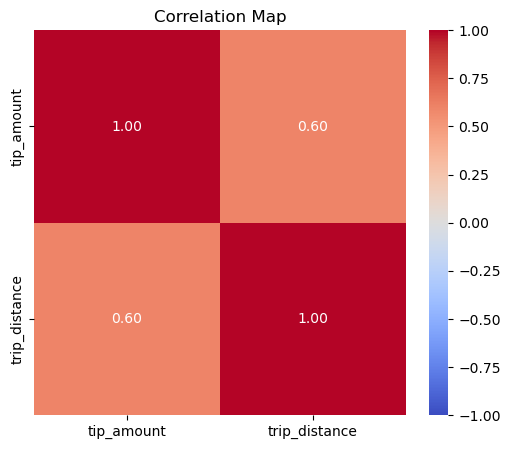

In [334]:
# Show relationship between tip and trip distance

corr = df2023_1[['tip_amount', 'trip_distance']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Map')
plt.show()


In [335]:
# Conclusion is
# Tip Amount and Trip Distance show a moderate positive correlation (r = 0.60). 
# This indicates that the Trip Distance has impact on the tip amount.

**3.1.8** 
Analyse the distribution of different payment types (`payment_type`)

In [338]:
df2023.to_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataAnalysis.csv", index=False)


In [339]:
df2023_1 = pd.read_csv(r"C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\DataAnalysis.csv")

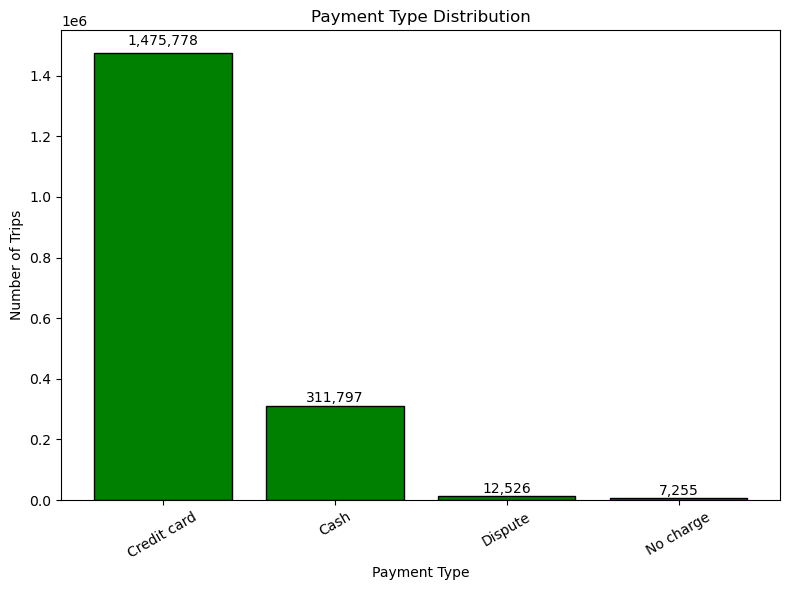

In [352]:
# Analyse the distribution of different payment types (payment_type).

# Count occurrences of each payment type
payment_counts = df2023_1['payment_type'].value_counts()

plt.figure(figsize=(8,6))
bars = plt.bar(payment_counts.index, payment_counts.values, color='green', edgecolor='black')

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01*height), 
             f'{height:,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [354]:
df2023_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1807356 entries, 0 to 1807355
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               object 
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             object 
 6   PULocationID           int64  
 7   DOLocationID           int64  
 8   payment_type           object 
 9   fare_amount            float64
 10  extra                  float64
 11  mta_tax                float64
 12  tip_amount             float64
 13  tolls_amount           float64
 14  improvement_surcharge  float64
 15  total_amount           float64
 16  congestion_surcharge   float64
 17  pickup_hour            int64  
 18  airport_fee            float64
 19  trip_duration_sec      float64
 20  pickup_day_name        object 
 21  pickup_month           object 
 22  pickup_quarter    

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [360]:
# !pip install geopandas

**3.1.9** 
Load the shapefile and display it.

In [363]:
import os
print(os.getcwd())


C:\Users\shank\anaconda_projects\Upgrad\Platform Materials - Course\C2Data Analysis and Exploration\Project\Starter Notebook - EDA NYC Taxi\Data


   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1        0.12        0.00           Newark Airport           1   
1         2        0.43        0.00              Jamaica Bay           2   
2         3        0.08        0.00  Allerton/Pelham Gardens           3   
3         4        0.04        0.00            Alphabet City           4   
4         5        0.09        0.00            Arden Heights           5   
5         6        0.15        0.00  Arrochar/Fort Wadsworth           6   
6         7        0.11        0.00                  Astoria           7   
7         8        0.03        0.00             Astoria Park           8   
8         9        0.10        0.00               Auburndale           9   
9        10        0.10        0.00             Baisley Park          10   

         borough                                           geometry  
0            EWR  POLYGON ((9.33e+05 1.93e+05, 9.33e+05 1.93e+05...  
1         Queens  MULTI

<Axes: >

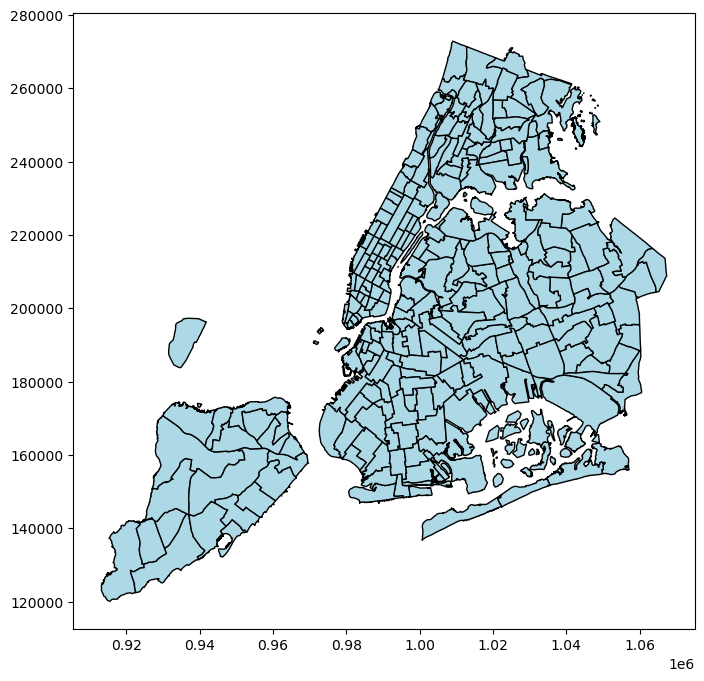

In [365]:
# import geopandas as gpd

import geopandas as gpd

# Read the shapefile
zones = gpd.read_file("taxi_zones/taxi_zones.shp")

# Quick check
print(zones.head(10))
# Plot all zones
zones.plot(figsize=(12, 8), edgecolor="black", color="lightblue")

# Read the shapefile using geopandas
#zones = # read the .shp file using gpd
#zones.head()

In [366]:
print(zones.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


In [367]:
zones["zone"].value_counts()

zone
Governor's Island/Ellis Island/Liberty Island    3
Corona                                           2
Newark Airport                                   1
Oakwood                                          1
Park Slope                                       1
                                                ..
Fordham South                                    1
Forest Hills                                     1
Forest Park/Highland Park                        1
Fort Greene                                      1
Yorkville West                                   1
Name: count, Length: 260, dtype: int64

In [368]:
zones["zone"].isnull().sum()

0

In [369]:
print(zones.head(10))

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1        0.12        0.00           Newark Airport           1   
1         2        0.43        0.00              Jamaica Bay           2   
2         3        0.08        0.00  Allerton/Pelham Gardens           3   
3         4        0.04        0.00            Alphabet City           4   
4         5        0.09        0.00            Arden Heights           5   
5         6        0.15        0.00  Arrochar/Fort Wadsworth           6   
6         7        0.11        0.00                  Astoria           7   
7         8        0.03        0.00             Astoria Park           8   
8         9        0.10        0.00               Auburndale           9   
9        10        0.10        0.00             Baisley Park          10   

         borough                                           geometry  
0            EWR  POLYGON ((9.33e+05 1.93e+05, 9.33e+05 1.93e+05...  
1         Queens  MULTI

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [376]:
# print(zones.info())
# zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** 
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [380]:
# Merge zones and trip records using locationID and PULocationID
merged_df = pd.merge(df2023_1, zones, left_on='PULocationID', right_on='LocationID', how='inner')
merged_df.head()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1789918 entries, 0 to 1789917
Data columns (total 30 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   VendorID               object  
 1   tpep_pickup_datetime   object  
 2   tpep_dropoff_datetime  object  
 3   passenger_count        float64 
 4   trip_distance          float64 
 5   RatecodeID             object  
 6   PULocationID           int64   
 7   DOLocationID           int64   
 8   payment_type           object  
 9   fare_amount            float64 
 10  extra                  float64 
 11  mta_tax                float64 
 12  tip_amount             float64 
 13  tolls_amount           float64 
 14  improvement_surcharge  float64 
 15  total_amount           float64 
 16  congestion_surcharge   float64 
 17  pickup_hour            int64   
 18  airport_fee            float64 
 19  trip_duration_sec      float64 
 20  pickup_day_name        object  
 21  pickup_month           object  

**3.1.11** 
Group data by location IDs to find the total number of trips per location ID

In [382]:
# Group data by location and calculate the number of trips

tripsperlocation = merged_df.groupby("PULocationID").size().reset_index(name="total_trips")
print(tripsperlocation)

     PULocationID  total_trips
0               1           61
1               2            2
2               3            3
3               4         1797
4               6           22
..            ...          ...
245           259            6
246           260          297
247           261         9525
248           262        23520
249           263        34712

[250 rows x 2 columns]


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [384]:
# Merge trip counts back to the zones GeoDataFrame

zones_merged = pd.merge(zones, tripsperlocation, left_on='LocationID', right_on='PULocationID', how='inner')

zones_merged.drop(["PULocationID"], axis=1, inplace=True)

zones_merged.head()
zones_merged.info()



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   OBJECTID     251 non-null    int32   
 1   Shape_Leng   251 non-null    float64 
 2   Shape_Area   251 non-null    float64 
 3   zone         251 non-null    object  
 4   LocationID   251 non-null    int32   
 5   borough      251 non-null    object  
 6   geometry     251 non-null    geometry
 7   total_trips  251 non-null    int64   
dtypes: float64(2), geometry(1), int32(2), int64(1), object(2)
memory usage: 13.9+ KB


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** 
Plot a color-coded map showing zone-wise trips

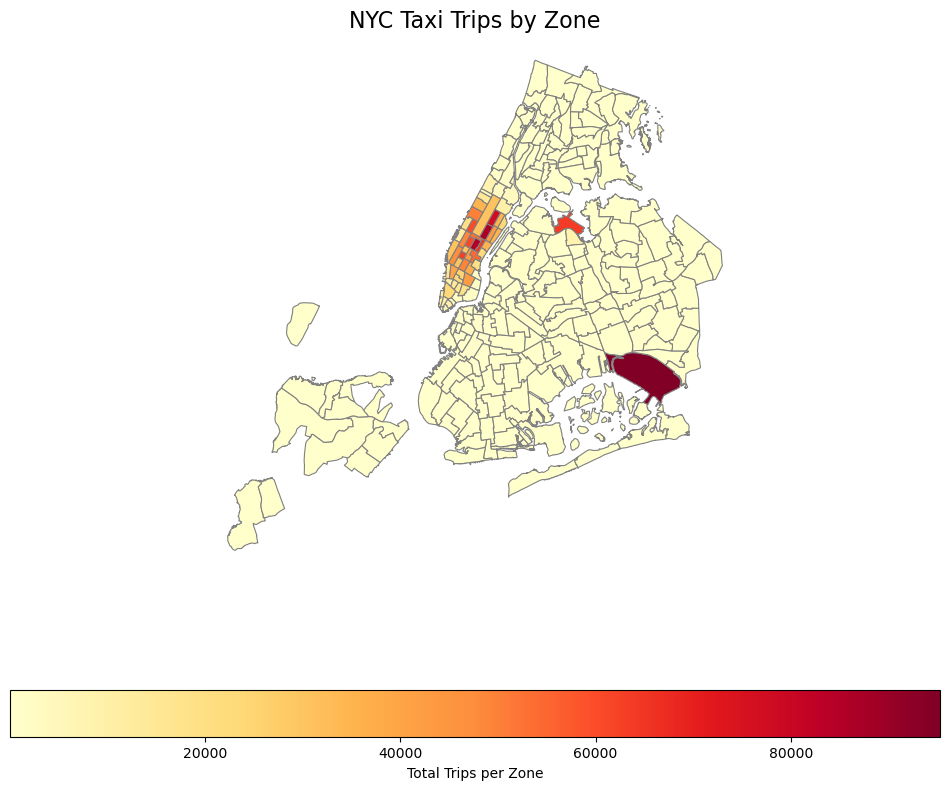

In [388]:
import matplotlib.pyplot as plt

# 1. Set up figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 2. Plot the GeoDataFrame as a choropleth
zones_merged.plot(
    column="total_trips",           # column to shade
    cmap="YlOrRd",                    # color map (Orange-Red)
    linewidth=0.8,                  # border line width
    edgecolor="gray",               # border color
    ax=ax,
    legend=True,                    # show legend
    legend_kwds={
        'label': "Total Trips per Zone",
        'orientation': "horizontal"
    }
)

# 3. Title and cleanup
ax.set_title("NYC Taxi Trips by Zone", fontsize=16)
ax.axis("off")

# 4. Show the plot
plt.show()


In [390]:
# can you try displaying the zones DF sorted by the number of trips?

print(zones_merged.sort_values(by='total_trips', ascending=False))


     OBJECTID  Shape_Leng  Shape_Area                                 zone  \
122       132        0.25        0.00                          JFK Airport   
225       237        0.04        0.00                Upper East Side South   
151       161        0.04        0.00                       Midtown Center   
224       236        0.04        0.00                Upper East Side North   
152       162        0.04        0.00                         Midtown East   
..        ...         ...         ...                                  ...   
25         27        0.20        0.00  Breezy Point/Fort Tilden/Riis Beach   
190       201        0.13        0.00                        Rockaway Park   
105       115        0.12        0.00                  Grymes Hill/Clifton   
162       172        0.12        0.00               New Dorp/Midland Beach   
43         46        0.13        0.00                          City Island   

     LocationID        borough  \
122         132         Queen

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** 
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

In [400]:
# 1. Copy your DataFrame
df = merged_df.copy()

# 2. Remove invalid/zero trips (to avoid divide by zero / garbage speeds)
df = df[(df["trip_distance"] > 0.1) & (df["trip_duration_sec"] > 60)]

# 3. Add average speed column (mph or km/h depending on your distance unit)
#    Assuming distance is in miles, convert seconds → hours
df["avg_speed"] = df["trip_distance"] / (df["trip_duration_sec"] / 3600)

# 4. Group by route + hour → calculate mean speed and mean trip time
route_speed = (
    df.groupby(["PULocationID", "DOLocationID", "pickup_hour"])
    .agg(
        avg_speed=("avg_speed", "mean"),
        avg_duration_min=("trip_duration_sec", lambda x: x.mean() / 60),
        trip_count=("avg_speed", "count")
    )
    .reset_index()
)

# 5. Identify "slow routes"
#    Sort by slowest avg speed (ascending), but keep only routes with enough trips (to avoid noise)
slow_routes = route_speed[route_speed["trip_count"] > 30].sort_values("avg_speed", ascending=True)

print(slow_routes.head(20))


       PULocationID  DOLocationID  pickup_hour  avg_speed  avg_duration_min  \
81421           186           100           12       3.48             12.74   
82101           186           164           12       3.74             31.43   
81425           186           100           16       3.81             10.99   
81420           186           100           11       3.93             13.45   
30228           100            48           13       3.93             14.15   
81422           186           100           13       3.98             12.03   
71593           162           230           13       4.00             15.73   
71597           162           230           17       4.04             15.22   
80911           186            48           13       4.04             16.30   
82640           186           230           12       4.08             23.39   
15591            68           100           11       4.09             13.80   
81424           186           100           15      

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

How does identifying high-traffic, high-demand routes help us?

**3.2.2** 
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [406]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1789918 entries, 0 to 1789917
Data columns (total 30 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   VendorID               object  
 1   tpep_pickup_datetime   object  
 2   tpep_dropoff_datetime  object  
 3   passenger_count        float64 
 4   trip_distance          float64 
 5   RatecodeID             object  
 6   PULocationID           int64   
 7   DOLocationID           int64   
 8   payment_type           object  
 9   fare_amount            float64 
 10  extra                  float64 
 11  mta_tax                float64 
 12  tip_amount             float64 
 13  tolls_amount           float64 
 14  improvement_surcharge  float64 
 15  total_amount           float64 
 16  congestion_surcharge   float64 
 17  pickup_hour            int64   
 18  airport_fee            float64 
 19  trip_duration_sec      float64 
 20  pickup_day_name        object  
 21  pickup_month           object  

In [407]:
trip_busy = (
    merged_df.groupby("pickup_hour")
    .agg(trip_count=("VendorID", "count"))
    .reset_index()
)
trip_busy.head(24)

,pickup_hour,trip_count
0,0,50107
1,1,33507
2,2,21975
3,3,14268
4,4,8879
5,5,9362
6,6,23368
7,7,47462
8,8,66383
9,9,76003


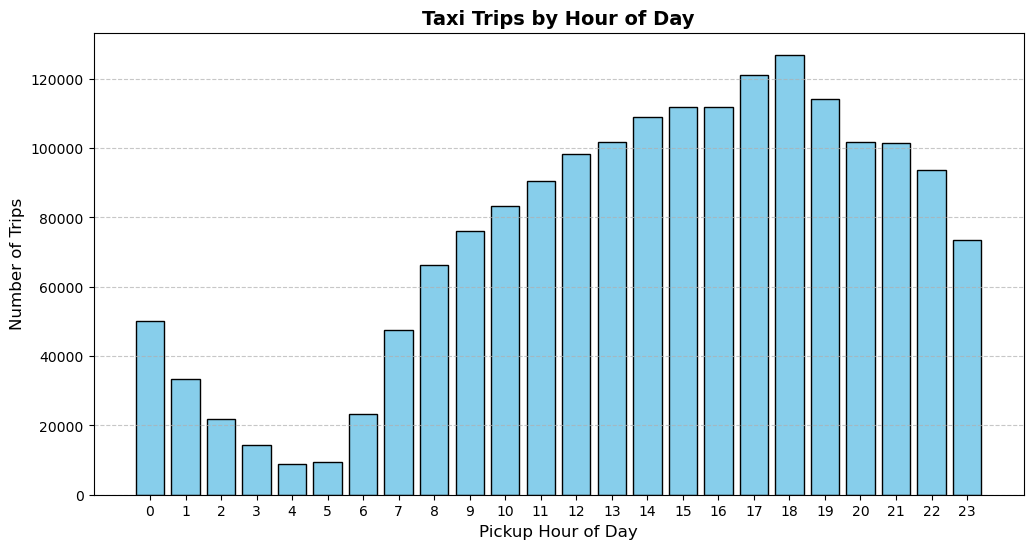

In [408]:
# Visualise the number of trips per hour and find the busiest hour
# Plot bar chart since hours are discrete
plt.figure(figsize=(12,6))
plt.bar(trip_busy["pickup_hour"], trip_busy["trip_count"], 
        width=0.8, color="skyblue", edgecolor="black")

# Labels and title
plt.xlabel("Pickup Hour of Day", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.title("Taxi Trips by Hour of Day", fontsize=14, fontweight="bold")

# Show all hours on x-axis
plt.xticks(range(24))

# Grid lines for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display plot
plt.show()

## Conclusion
1. Least no of trips is at 4th and 5th hour.
2. Max number of trips is at 17, 18 and 19th ... Max being 18th Hour.
3. All other hours it is moderate.
4. This is left skewed distribution.

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

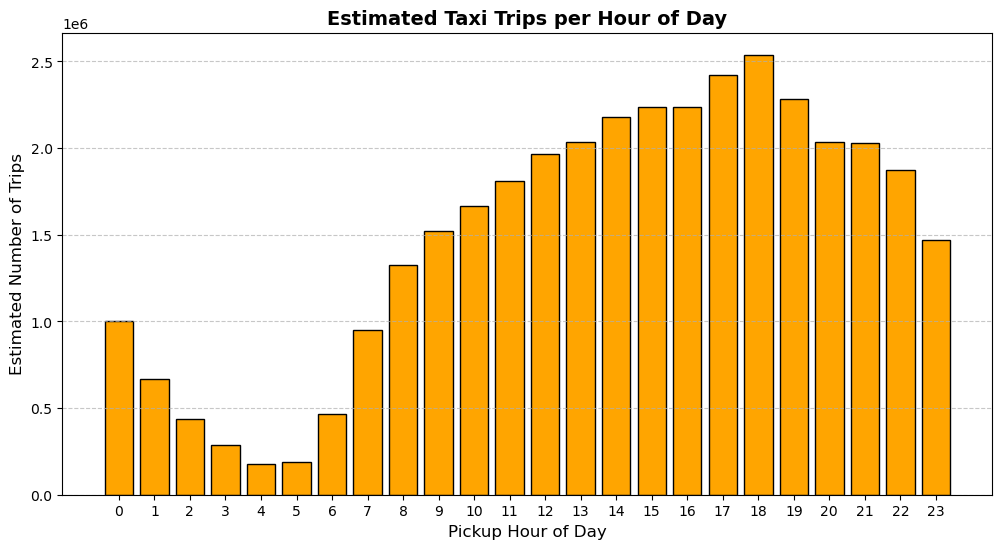

In [411]:
trip_busy = pd.DataFrame(trip_busy)

# Define your sampling ratio (example: 1% of trips taken)
sampling_ratio = 0.05
scaling_factor = 1 / sampling_ratio

# Scale trip counts to estimate actual total trips
trip_busy["actual_trip_count"] = trip_busy["trip_count"] * scaling_factor

# Plot histogram with scaled counts
plt.figure(figsize=(12,6))
plt.bar(trip_busy["pickup_hour"], trip_busy["actual_trip_count"], 
        width=0.8, color="orange", edgecolor="black")

plt.xlabel("Pickup Hour of Day", fontsize=12)
plt.ylabel("Estimated Number of Trips", fontsize=12)
plt.title("Estimated Taxi Trips per Hour of Day", fontsize=14, fontweight="bold")
plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

**3.2.3** Find the actual number of trips in the five busiest hours

In [413]:
# Scale up the number of trips
trip_busy["actual_trip_count"] = trip_busy["trip_count"] * 20

# Sort by original trip count
trip_busy = trip_busy.sort_values("actual_trip_count", ascending = False)

# Show top 24 rows
trip_busy.head(5)


,pickup_hour,trip_count,actual_trip_count
18,18,126936,2538720
17,17,121206,2424120
19,19,114042,2280840
15,15,111803,2236060
16,16,111768,2235360


**3.2.4** Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [415]:
merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_day_name,pickup_month,pickup_quarter,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,VeriFone Inc.,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.86,Standard rate,141,140,Credit card,6.50,...,Saturday,December,Q4,141,0.04,0.00,Lenox Hill West,141,Manhattan,"POLYGON ((9.95e+05 2.16e+05, 9.95e+05 2.16e+05..."
1,VeriFone Inc.,2023-01-01 00:07:18,2023-01-01 00:23:15,1.00,7.74,Standard rate,138,256,Cash,32.40,...,Sunday,January,Q1,138,0.11,0.00,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1.02e+06 2.26e+05, 1.02e+06 2...."
2,VeriFone Inc.,2023-01-01 00:16:41,2023-01-01 00:21:46,2.00,1.24,Standard rate,161,237,Credit card,7.90,...,Sunday,January,Q1,161,0.04,0.00,Midtown Center,161,Manhattan,"POLYGON ((9.91e+05 2.14e+05, 9.91e+05 2.14e+05..."
3,VeriFone Inc.,2023-01-01 00:14:03,2023-01-01 00:24:36,3.00,1.44,Standard rate,237,141,Cash,11.40,...,Sunday,January,Q1,237,0.04,0.00,Upper East Side South,237,Manhattan,"POLYGON ((9.94e+05 2.17e+05, 9.94e+05 2.17e+05..."
4,VeriFone Inc.,2023-01-01 00:24:30,2023-01-01 00:29:55,1.00,0.54,Standard rate,143,142,Cash,6.50,...,Sunday,January,Q1,143,0.05,0.00,Lincoln Square West,143,Manhattan,"POLYGON ((9.89e+05 2.24e+05, 9.89e+05 2.24e+05..."


In [416]:
# Compare traffic trends for the week days and weekends
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekends = ["Saturday", "Sunday"]
# Filter the DataFrame
trip_weekdays = merged_df[merged_df["pickup_day_name"].isin(weekdays)]
trip_weekends = merged_df[merged_df["pickup_day_name"].isin(weekends)]
# Preview the result

print(trip_weekends.head())

trip_weekdays.head()

        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0  VeriFone Inc.  2022-12-31 23:51:30   2022-12-31 23:56:06             1.00   
1  VeriFone Inc.  2023-01-01 00:07:18   2023-01-01 00:23:15             1.00   
2  VeriFone Inc.  2023-01-01 00:16:41   2023-01-01 00:21:46             2.00   
3  VeriFone Inc.  2023-01-01 00:14:03   2023-01-01 00:24:36             3.00   
4  VeriFone Inc.  2023-01-01 00:24:30   2023-01-01 00:29:55             1.00   

   trip_distance     RatecodeID  PULocationID  DOLocationID payment_type  \
0           0.86  Standard rate           141           140  Credit card   
1           7.74  Standard rate           138           256         Cash   
2           1.24  Standard rate           161           237  Credit card   
3           1.44  Standard rate           237           141         Cash   
4           0.54  Standard rate           143           142         Cash   

   fare_amount  ...  pickup_day_name  pickup_month  pickup_qua

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_day_name,pickup_month,pickup_quarter,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
3502,VeriFone Inc.,2023-01-02 00:37:52,2023-01-02 00:46:51,1.00,1.84,Standard rate,246,161,Credit card,11.40,...,Monday,January,Q1,246,0.07,0.00,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((9.83e+05 2.17e+05, 9.84e+05 2.17e+05..."
3503,VeriFone Inc.,2023-01-02 00:43:13,2023-01-02 00:54:59,1.00,3.10,Standard rate,249,13,Credit card,15.60,...,Monday,January,Q1,249,0.04,0.00,West Village,249,Manhattan,"POLYGON ((9.84e+05 2.05e+05, 9.83e+05 2.05e+05..."
3504,VeriFone Inc.,2023-01-02 00:27:08,2023-01-02 00:58:02,1.00,16.99,Standard rate,132,256,Cash,64.60,...,Monday,January,Q1,132,0.25,0.00,JFK Airport,132,Queens,"MULTIPOLYGON (((1.03e+06 1.81e+05, 1.03e+06 1...."
3505,VeriFone Inc.,2023-01-02 00:08:35,2023-01-02 00:30:12,1.00,7.70,Standard rate,132,91,Credit card,33.80,...,Monday,January,Q1,132,0.25,0.00,JFK Airport,132,Queens,"MULTIPOLYGON (((1.03e+06 1.81e+05, 1.03e+06 1...."
3506,VeriFone Inc.,2023-01-02 00:44:44,2023-01-02 00:57:00,1.00,7.59,Standard rate,138,263,Credit card,30.30,...,Monday,January,Q1,138,0.11,0.00,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1.02e+06 2.26e+05, 1.02e+06 2...."


In [417]:
# Compare traffic trends for the week days and weekends
trip_weekdays = trip_weekdays[(trip_weekdays["trip_distance"] > 0.1) & (trip_weekdays["trip_duration_sec"] > 60)]

trip_weekdays["avg_speed"] = trip_weekdays["trip_distance"] / (trip_weekdays["trip_duration_sec"] / 3600)

# 4. Group by route + hour → calculate mean speed and mean trip time
route_speed = (
    trip_weekdays.groupby(["pickup_hour"])
    .agg(
        avg_speed=("avg_speed", "mean"),
        avg_duration_min=("trip_duration_sec", lambda x: x.mean() / 60),
        trip_count=("avg_speed", "count")
    )
    .reset_index()
)

route_speed["avg_trip_count"] = route_speed["trip_count"]/5
#Weekdays = route_speed[route_speed["trip_count"] > 30].sort_values("avg_speed", ascending=True)

print(route_speed.head(24))


    pickup_hour  avg_speed  avg_duration_min  trip_count  avg_trip_count
0             0      16.66             15.89       24742         4948.40
1             1      17.06             14.73       12560         2512.00
2             2      16.97             14.37        6736         1347.20
3             3      18.22             15.50        4125          825.00
4             4      21.67             16.35        3548          709.60
5             5      20.05             14.95        6931         1386.20
6             6      15.90             15.43       19323         3864.60
7             7      12.38             15.60       41067         8213.40
8             8      10.32             16.45       56338        11267.60
9             9      10.00             17.35       60207        12041.40
10           10       9.72             17.95       62128        12425.60
11           11       9.33             18.44       65566        13113.20
12           12       9.41             18.52       

In [418]:
# Compare traffic trends for the week days and weekends
trip_weekends = trip_weekends[(trip_weekends["trip_distance"] > 0.1) & (trip_weekends["trip_duration_sec"] > 60)]

trip_weekends["avg_speed"] = trip_weekends["trip_distance"] / (trip_weekends["trip_duration_sec"] / 3600)

# 4. Group by route + hour → calculate mean speed and mean trip time
route_speed1 = (
    trip_weekends.groupby(["pickup_hour"])
    .agg(
        avg_speed=("avg_speed", "mean"),
        avg_duration_min=("trip_duration_sec", lambda x: x.mean() / 60),
        trip_count=("avg_speed", "count")
    )
    .reset_index()
)

route_speed1["avg_trip_count"] = route_speed1["trip_count"]/2
#Weekdays = route_speed[route_speed["trip_count"] > 30].sort_values("avg_speed", ascending=True)

print(route_speed1.head(50))


    pickup_hour  avg_speed  avg_duration_min  trip_count  avg_trip_count
0             0      12.65             15.65       24952        12476.00
1             1      12.97             15.16       20631        10315.50
2             2      13.62             14.13       14976         7488.00
3             3      14.58             13.30        9959         4979.50
4             4      16.76             15.46        5158         2579.00
5             5      22.23             17.93        2258         1129.00
6             6      21.96             15.94        3770         1885.00
7             7      19.78             14.89        5968         2984.00
8             8      16.90             12.77        9490         4745.00
9             9      14.93             13.11       15141         7570.50
10           10      13.41             13.96       20426        10213.00
11           11      12.12             14.50       24112        12056.00
12           12      11.49             15.59       

In [419]:
print("Max weekday speed:", route_speed['avg_speed'].max())
print("Max weekend speed:", route_speed1['avg_speed'].max())


Max weekday speed: 21.668242840232843
Max weekend speed: 22.233609675949857


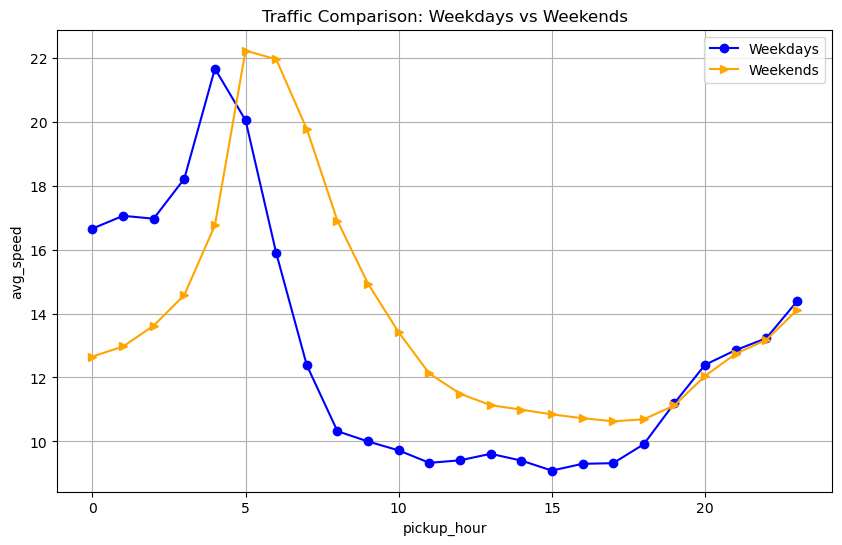

In [420]:
plt.figure(figsize=(10, 6))

plt.plot(route_speed['pickup_hour'] , route_speed['avg_speed'], label='Weekdays', color='blue', marker='o')
plt.plot(route_speed1['pickup_hour'], route_speed1['avg_speed'], label='Weekends', color='orange', marker='>')

plt.xlabel('pickup_hour')
plt.ylabel('avg_speed')
plt.title('Traffic Comparison: Weekdays vs Weekends')
plt.legend()
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

In [422]:
## Conclusion
#1. From Midnight to morning 5 the average speed is slower than weekdays.
#2. From 5 to 19 the average speed is more in Weekends.
#3. From 19 to 23 the speed is almost similar.

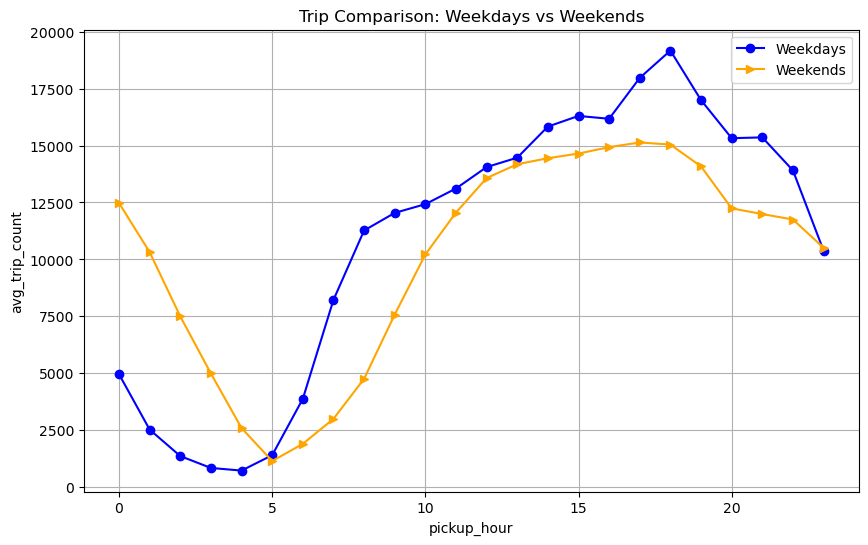

In [423]:
plt.figure(figsize=(10, 6))

plt.plot(route_speed['pickup_hour'] , route_speed['avg_trip_count'], label='Weekdays', color='blue', marker='o')
plt.plot(route_speed1['pickup_hour'], route_speed1['avg_trip_count'], label='Weekends', color='orange', marker='>')

plt.xlabel('pickup_hour')
plt.ylabel('avg_trip_count')
plt.title('Trip Comparison: Weekdays vs Weekends')
plt.legend()
plt.grid(True)
plt.show()

In [424]:
## Conclusion
#1. From Midnight to morning 5 the average trip count is less in weekdays.
#2. From 5 to 23 the average trip count is more in Weekdays.
#3. At the 12th and 13th hour the trip counts on weekdays and weekends is almost same.
#4 At the 18th hour the trip count is proprotionally more than then at the same time on weekends.
#5 At midnight people travelling by cabs are more on Weekends.

**3.2.5** 
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [426]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1789918 entries, 0 to 1789917
Data columns (total 30 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   VendorID               object  
 1   tpep_pickup_datetime   object  
 2   tpep_dropoff_datetime  object  
 3   passenger_count        float64 
 4   trip_distance          float64 
 5   RatecodeID             object  
 6   PULocationID           int64   
 7   DOLocationID           int64   
 8   payment_type           object  
 9   fare_amount            float64 
 10  extra                  float64 
 11  mta_tax                float64 
 12  tip_amount             float64 
 13  tolls_amount           float64 
 14  improvement_surcharge  float64 
 15  total_amount           float64 
 16  congestion_surcharge   float64 
 17  pickup_hour            int64   
 18  airport_fee            float64 
 19  trip_duration_sec      float64 
 20  pickup_day_name        object  
 21  pickup_month           object  

In [427]:
# Find top 10 pickup and dropoff zones

pickup_counts = (
    merged_df.groupby(['PULocationID', 'pickup_hour'])
    .size()
    .reset_index(name='trip_count')
)

top10_pickups = (
    pickup_counts.groupby('PULocationID')['trip_count']
    .sum()
    .nlargest(10)
    .index
)

print(top10_pickups)

# 4. Filter pickup trends for top 10
pickup_trends = pickup_counts[pickup_counts['PULocationID'].isin(top10_pickups)]


######
merged_df['tpep_pickup_datetime'] = pd.to_datetime(merged_df['tpep_pickup_datetime'])
merged_df['tpep_dropoff_datetime'] = pd.to_datetime(merged_df['tpep_dropoff_datetime'])
merged_df["dropoff_hour"] = merged_df["tpep_dropoff_datetime"].dt.hour

dropoff_counts = (
    merged_df.groupby(['DOLocationID', 'dropoff_hour'])
    .size()
    .reset_index(name='trip_count')
)

# Find top 10 dropoff zones overall
top10_dropoffs = (
    dropoff_counts.groupby('DOLocationID')['trip_count']
    .sum()
    .nlargest(10)
    .index
)

dropoff_trends = dropoff_counts[dropoff_counts['DOLocationID'].isin(top10_dropoffs)]
print(top10_dropoffs)


Index([132, 237, 161, 236, 162, 138, 186, 230, 142, 170], dtype='int64', name='PULocationID')
Index([236, 237, 161, 230, 170, 162, 142, 239, 141, 68], dtype='int64', name='DOLocationID')


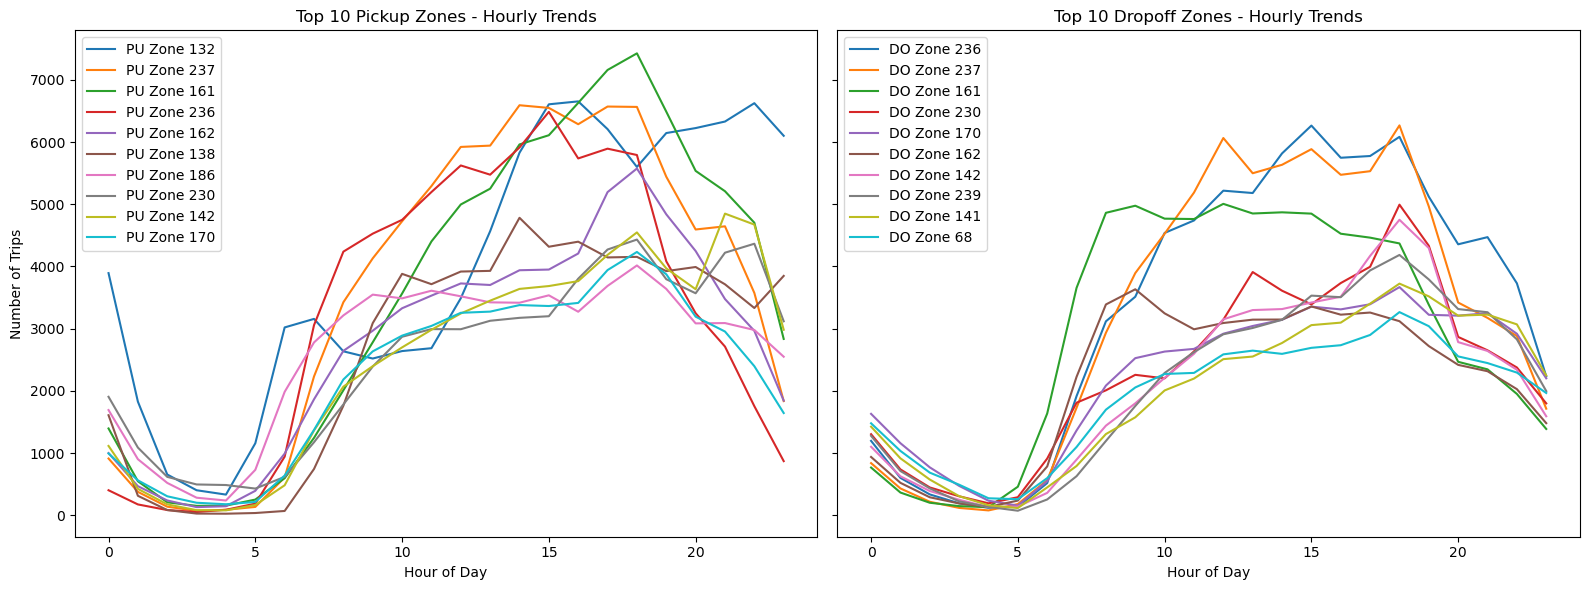

In [428]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# Pickup trends
for zone in top10_pickups:
    zone_data = pickup_trends[pickup_trends['PULocationID'] == zone]
    axes[0].plot(zone_data['pickup_hour'], zone_data['trip_count'], label=f'PU Zone {zone}')

axes[0].set_title("Top 10 Pickup Zones - Hourly Trends")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Trips")
axes[0].legend()

# Dropoff trends
for zone in top10_dropoffs:
    zone_data = dropoff_trends[dropoff_trends['DOLocationID'] == zone]
    axes[1].plot(zone_data['dropoff_hour'], zone_data['trip_count'], label=f'DO Zone {zone}')

axes[1].set_title("Top 10 Dropoff Zones - Hourly Trends")
axes[1].set_xlabel("Hour of Day")
axes[1].legend()

plt.tight_layout()
plt.show()

**3.2.6** 
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [430]:
import pandas as pd

# 1. Count pickups per zone
pickup_counts = (
    merged_df.groupby("PULocationID")
    .size()
    .reset_index(name="pickups")
)

# 2. Count dropoffs per zone
dropoff_counts = (
    merged_df.groupby("DOLocationID")
    .size()
    .reset_index(name="dropoffs")
)

# 3. Merge on zone ID
zone_counts = pd.merge(
    pickup_counts, dropoff_counts,
    left_on="PULocationID", right_on="DOLocationID", how="outer"
)

# 4. Clean up column names
zone_counts["ZoneID"] = zone_counts["PULocationID"].fillna(zone_counts["DOLocationID"])
zone_counts = zone_counts[["ZoneID", "pickups", "dropoffs"]]

# Fill NaN with 0
zone_counts = zone_counts.fillna(0)

# 5. Remove zones where pickups or dropoffs = 0
zone_counts = zone_counts[(zone_counts["pickups"] > 0) & (zone_counts["dropoffs"] > 0)]

# 6. Compute pickup-to-dropoff ratio
zone_counts["pickup_drop_ratio"] = zone_counts["pickups"] / zone_counts["dropoffs"]

# 7. Find top 10 and bottom 10 zones by ratio
top10_ratios = zone_counts.sort_values("pickup_drop_ratio", ascending=False).head(10)
bottom10_ratios = zone_counts.sort_values("pickup_drop_ratio", ascending=True).head(10)

print("🔝 Top 10 Pickup/Dropoff Ratios (excluding 0s)")
print(top10_ratios)

print("\n🔻 Bottom 10 Pickup/Dropoff Ratios (excluding 0s)")
print(bottom10_ratios)


🔝 Top 10 Pickup/Dropoff Ratios (excluding 0s)
     ZoneID  pickups  dropoffs  pickup_drop_ratio
69    70.00  8199.00    868.00               9.45
127  132.00 95298.00  19452.00               4.90
133  138.00 63813.00  21812.00               2.93
181  186.00 63201.00  39756.00               1.59
42    43.00 30675.00  22238.00               1.38
109  114.00 24021.00  17441.00               1.38
244  249.00 40275.00  30298.00               1.33
157  162.00 65372.00  51890.00               1.26
156  161.00 85612.00  71207.00               1.20
99   100.00 30033.00  25108.00               1.20

🔻 Bottom 10 Pickup/Dropoff Ratios (excluding 0s)
     ZoneID  pickups  dropoffs  pickup_drop_ratio
196  201.00     1.00    163.00               0.01
222  227.00     3.00    273.00               0.01
0      1.00    61.00   5137.00               0.01
134  139.00     4.00    322.00               0.01
31    32.00     2.00    102.00               0.02
252  257.00    15.00    744.00               0.02
247 

**3.2.7** 
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [432]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
import pandas as pd

# Ensure datetime columns are in datetime format
merged_df['tpep_pickup_datetime'] = pd.to_datetime(merged_df['tpep_pickup_datetime'])
merged_df['tpep_dropoff_datetime'] = pd.to_datetime(merged_df['tpep_dropoff_datetime'])

# Extract hours
merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour
merged_df['dropoff_hour'] = merged_df['tpep_dropoff_datetime'].dt.hour

# Define night hours (11PM–5AM)
night_hours = list(range(23, 24)) + list(range(0, 6))   # [23,0,1,2,3,4,5]

# --- Night pickups ---
night_pickups = (
    merged_df[merged_df['pickup_hour'].isin(night_hours)]
    .groupby('PULocationID')
    .size()
    .reset_index(name='pickup_count')
    .sort_values('pickup_count', ascending=False)
    .head(10)
)

# --- Night dropoffs ---
night_dropoffs = (
    merged_df[merged_df['dropoff_hour'].isin(night_hours)]
    .groupby('DOLocationID')
    .size()
    .reset_index(name='dropoff_count')
    .sort_values('dropoff_count', ascending=False)
    .head(10)
)

print(" Top 10 Pickup Zones (11PM–5AM)")
print(night_pickups)

print("\n Top 10 Dropoff Zones (11PM–5AM)")
print(night_dropoffs)


 Top 10 Pickup Zones (11PM–5AM)
     PULocationID  pickup_count
66             79         15474
104           132         14370
202           249         12413
38             48         10391
120           148          9575
90            114          8713
184           230          8144
150           186          6916
134           164          6093
55             68          5991

 Top 10 Dropoff Zones (11PM–5AM)
     DOLocationID  dropoff_count
77             79           8801
46             48           7374
163           170           6627
66             68           6191
101           107           6100
134           141           5751
254           263           5429
240           249           5262
221           230           5079
230           239           4853


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** 
Find the revenue share for nighttime and daytime hours.

In [434]:
# Filter for night hours (11 PM to 5 AM)

# Ensure datetime column is in datetime format
merged_df['tpep_pickup_datetime'] = pd.to_datetime(merged_df['tpep_pickup_datetime'])

# Extract pickup hour
merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour

# Define time windows
night_hours = list(range(23, 24)) + list(range(0, 6))   # 11PM–5AM
day_hours = list(range(6, 23))                         # 6AM–10PM

# --- Nighttime revenue ---
night_revenue = merged_df[merged_df['pickup_hour'].isin(night_hours)]['total_amount'].sum()

# --- Daytime revenue ---
day_revenue = merged_df[merged_df['pickup_hour'].isin(day_hours)]['total_amount'].sum()

# --- Total revenue ---
total_revenue = night_revenue + day_revenue

# --- Revenue share ---
night_share = (night_revenue / total_revenue) * 100
day_share = (day_revenue / total_revenue) * 100

print(f" Night Revenue (11PM–5AM): ${night_revenue:,.2f} ({night_share:.2f}% of total)")
print(f" Day Revenue   (6AM–10PM): ${day_revenue:,.2f} ({day_share:.2f}% of total)")
print(f" Total Revenue:             ${total_revenue:,.2f}")


 Night Revenue (11PM–5AM): $6,177,302.23 (12.02% of total)
 Day Revenue   (6AM–10PM): $45,217,022.20 (87.98% of total)
 Total Revenue:             $51,394,324.43


##### Pricing Strategy

**3.2.9** 
For the different passenger counts, find the average fare per mile per passenger.
For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [437]:
# Filter out trips with zero distance or zero passengers to avoid division by zero
df_filtered = merged_df[(merged_df['trip_distance'] > 0) & (merged_df['passenger_count'] > 0)]

# Calculate fare per mile per passenger
df_filtered['fare_per_mile_per_passenger'] = df_filtered['fare_amount'] / (df_filtered['trip_distance'] * df_filtered['passenger_count'])

# Group by passenger count and find average fare per mile per passenger
avg_fare_per_passenger = df_filtered.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print(avg_fare_per_passenger)



   passenger_count  fare_per_mile_per_passenger
0             1.00                        10.81
1             2.00                         6.35
2             3.00                         3.90
3             4.00                         4.22
4             5.00                         1.71
5             6.00                         1.35


C:\Users\shank\AppData\Local\Temp\ipykernel_30032\1246739966.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fare_per_mile_per_passenger'] = df_filtered['fare_amount'] / (df_filtered['trip_distance'] * df_filtered['passenger_count'])


In [438]:
df_filtered.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_quarter,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,dropoff_hour,fare_per_mile_per_passenger
0,VeriFone Inc.,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.86,Standard rate,141,140,Credit card,6.50,...,Q4,141,0.04,0.00,Lenox Hill West,141,Manhattan,"POLYGON ((9.95e+05 2.16e+05, 9.95e+05 2.16e+05...",23,7.56
1,VeriFone Inc.,2023-01-01 00:07:18,2023-01-01 00:23:15,1.00,7.74,Standard rate,138,256,Cash,32.40,...,Q1,138,0.11,0.00,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1.02e+06 2.26e+05, 1.02e+06 2....",0,4.19
2,VeriFone Inc.,2023-01-01 00:16:41,2023-01-01 00:21:46,2.00,1.24,Standard rate,161,237,Credit card,7.90,...,Q1,161,0.04,0.00,Midtown Center,161,Manhattan,"POLYGON ((9.91e+05 2.14e+05, 9.91e+05 2.14e+05...",0,3.19
3,VeriFone Inc.,2023-01-01 00:14:03,2023-01-01 00:24:36,3.00,1.44,Standard rate,237,141,Cash,11.40,...,Q1,237,0.04,0.00,Upper East Side South,237,Manhattan,"POLYGON ((9.94e+05 2.17e+05, 9.94e+05 2.17e+05...",0,2.64
4,VeriFone Inc.,2023-01-01 00:24:30,2023-01-01 00:29:55,1.00,0.54,Standard rate,143,142,Cash,6.50,...,Q1,143,0.05,0.00,Lincoln Square West,143,Manhattan,"POLYGON ((9.89e+05 2.24e+05, 9.89e+05 2.24e+05...",0,12.04


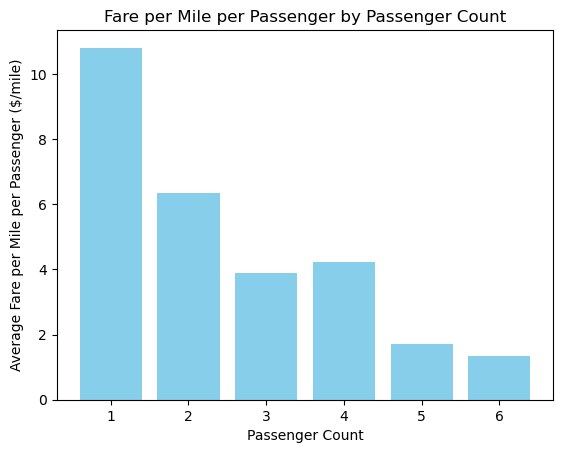

In [439]:
# Analyse the fare per mile per passenger for different passenger counts

# Visualization
plt.bar(avg_fare_per_passenger['passenger_count'], avg_fare_per_passenger['fare_per_mile_per_passenger'], color='skyblue')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare per Mile per Passenger ($/mile)')
plt.title('Fare per Mile per Passenger by Passenger Count')
plt.show()



**3.2.10** 
Find the average fare per mile by hours of the day and by days of the week

In [441]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1789918 entries, 0 to 1789917
Data columns (total 31 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int32         
 18  airport_fee           

In [442]:
# Compare the average fare per mile for different days and for different times of the day

avg_fare = (
    merged_df.groupby(["pickup_day_name","pickup_hour"])
    .agg(
        fare_amount=("fare_amount", "mean"),
        #avg_duration_min=("trip_duration_sec", lambda x: x.mean() / 60),
        #trip_count=("avg_speed", "count")
    )
    .reset_index()
)
avg_fare

,pickup_day_name,pickup_hour,fare_amount
0,Friday,0,19.12
1,Friday,1,18.08
2,Friday,2,16.91
3,Friday,3,19.17
4,Friday,4,25.69
...,...,...,...
163,Wednesday,19,17.73
164,Wednesday,20,18.10
165,Wednesday,21,18.36
166,Wednesday,22,18.85


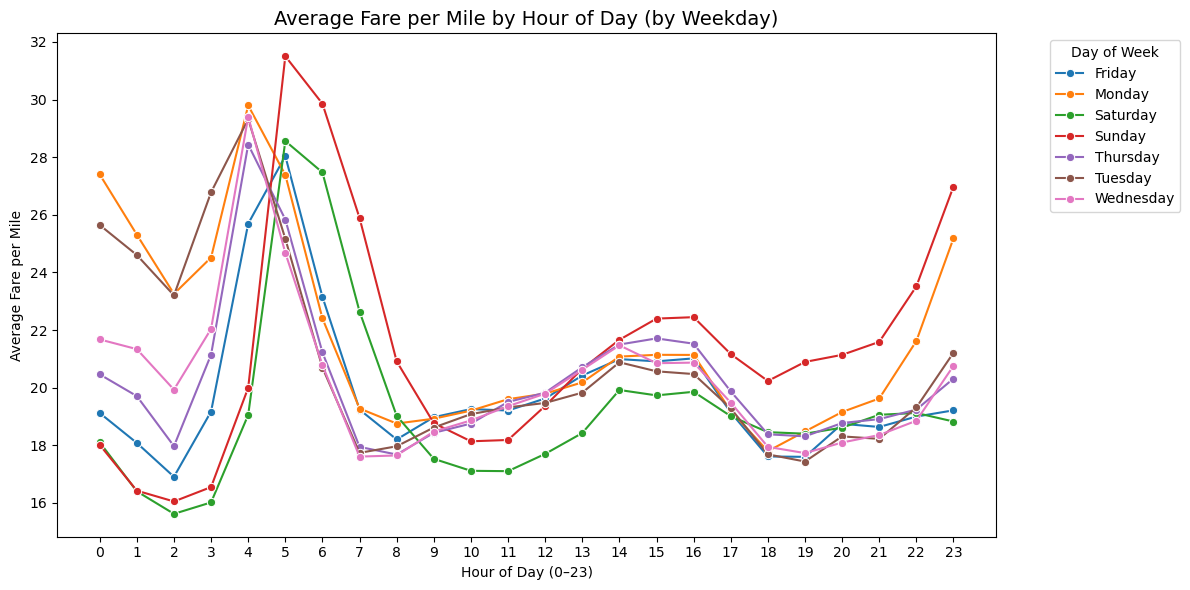

In [443]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_fare,
    x="pickup_hour",
    y="fare_amount",
    hue="pickup_day_name",
    marker="o"
)

plt.title("Average Fare per Mile by Hour of Day (by Weekday)", fontsize=14)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Fare per Mile")
plt.xticks(range(0,24))
plt.legend(title="Day of Week", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion
1. Fares are higher from 4th to 6th hour ofthe day
2. Least fares are during 2-3 hour of the day.
3. During evening the hours 18, 19, 20 is also having lower fares.
4. Sunday on an average is having the fare higher post 4 AM, compare to different days.
5. Weekdays the average fares seems to be similar most of the hour during the day (Except midnight to 5).

**3.2.11** 
Analyse the average fare per mile for the different vendors for different hours of the day

In [446]:
# Compare fare per mile for different vendors
# Compare the average fare per mile for different days and for different times of the day
# cleanup of the data where fare amount and trip disctance is equal to 0
merged_df = merged_df[(merged_df["fare_amount"] > 0) & (merged_df["trip_distance"] > 0)]
merged_df.loc[:, "fare_per_mile"] = merged_df["fare_amount"] / merged_df["trip_distance"]
avg_fare_per_mile = (
    merged_df.groupby(["VendorID","pickup_hour"])
    .agg(
        fare_per_mile=("fare_per_mile", "mean")
    )
    .reset_index()
)
avg_fare_per_mile

,VendorID,pickup_hour,fare_per_mile
0,"Creative Mobile Technologies, LLC",0,6.71
1,"Creative Mobile Technologies, LLC",1,7.02
2,"Creative Mobile Technologies, LLC",2,6.80
3,"Creative Mobile Technologies, LLC",3,6.52
4,"Creative Mobile Technologies, LLC",4,6.77
5,"Creative Mobile Technologies, LLC",5,6.75
6,"Creative Mobile Technologies, LLC",6,6.48
7,"Creative Mobile Technologies, LLC",7,7.13
8,"Creative Mobile Technologies, LLC",8,7.98
9,"Creative Mobile Technologies, LLC",9,8.36


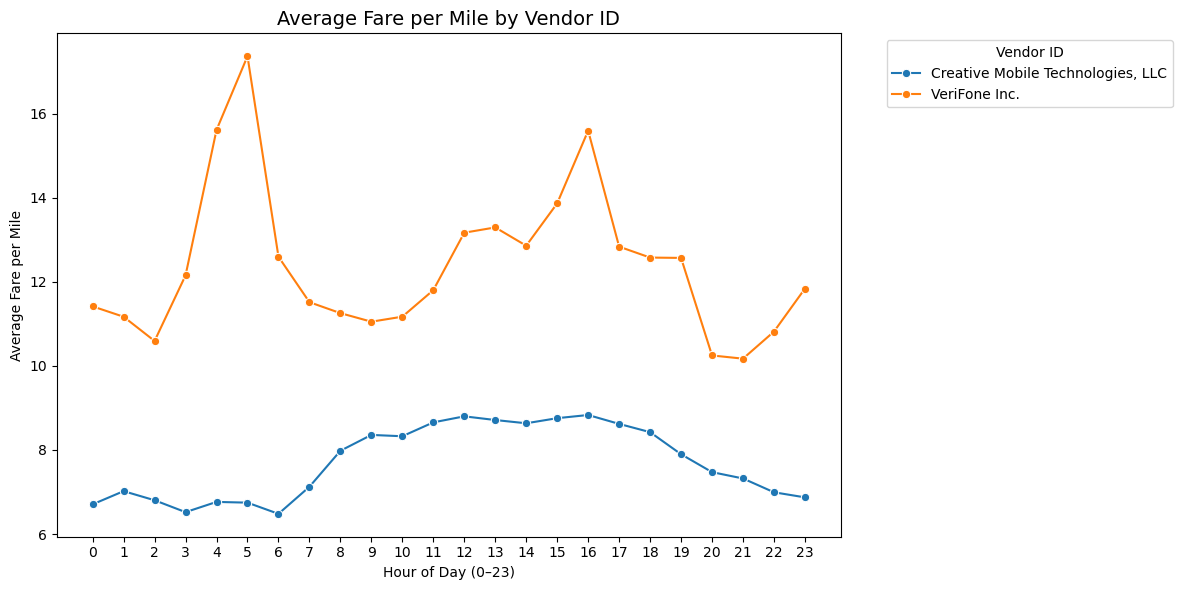

In [447]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_fare_per_mile,
    x="pickup_hour",
    y="fare_per_mile",
    hue="VendorID",
    marker="o"
)

plt.title("Average Fare per Mile by Vendor ID", fontsize=14)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Fare per Mile")
plt.xticks(range(0,24))
plt.legend(title="Vendor ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.12** 
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [449]:
# Defining distance tiers
# Define bins and labels
bins = [0, 2, 5, merged_df["trip_distance"].max()]
labels = ["0–2 miles", "2–5 miles", "5+ miles"]

merged_df["distance_tier"] = pd.cut(merged_df["trip_distance"], bins=bins, labels=labels, right=True)

print(merged_df["distance_tier"])

0          0–2 miles
1           5+ miles
2          0–2 miles
3          0–2 miles
4          0–2 miles
             ...    
1789913    0–2 miles
1789914    0–2 miles
1789915    0–2 miles
1789916     5+ miles
1789917    2–5 miles
Name: distance_tier, Length: 1782603, dtype: category
Categories (3, object): ['0–2 miles' < '2–5 miles' < '5+ miles']


In [450]:

####
avg_fare_tiered = (
    merged_df.groupby(["VendorID", "distance_tier"])
    .agg(avg_fare_per_mile=("fare_per_mile", "mean"),
         trip_count=("fare_per_mile", "count"))
    .reset_index()
)
####


C:\Users\shank\AppData\Local\Temp\ipykernel_30032\3232118418.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby(["VendorID", "distance_tier"])


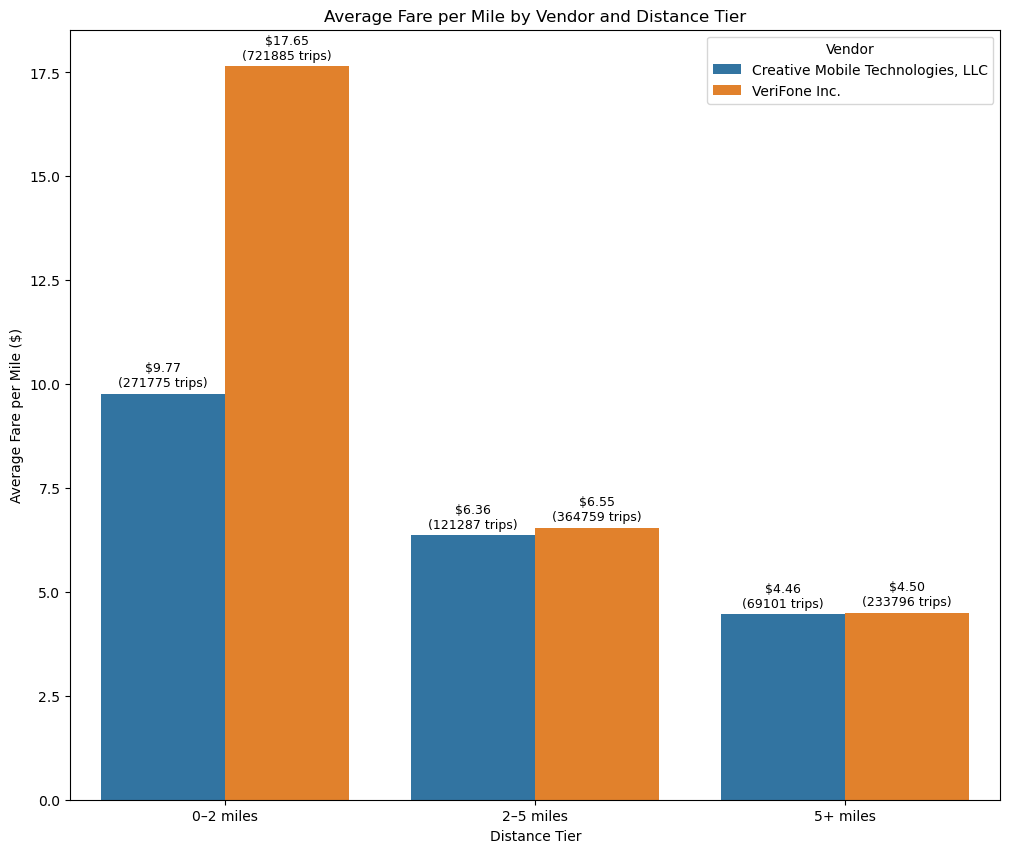

In [451]:
plt.figure(figsize=(12,10))
ax = sns.barplot(
    data=avg_fare_tiered,
    x="distance_tier", 
    y="avg_fare_per_mile", 
    hue="VendorID"
)

# Add both fare-per-mile and trip count
for p, trip_count in zip(ax.patches, avg_fare_tiered["trip_count"]):
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(
            f"${height:.2f}\n({trip_count} trips)",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 3), textcoords='offset points'
        )

plt.title("Average Fare per Mile by Vendor and Distance Tier")
plt.ylabel("Average Fare per Mile ($)")
plt.xlabel("Distance Tier")
plt.legend(title="Vendor")
plt.show()

##### Customer Experience and Other Factors

**3.2.13** 
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [454]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Filter out invalid fares
merged_df = merged_df[merged_df["fare_amount"] > 0].copy()
merged_df = merged_df[merged_df["passenger_count"] > 0].copy()
# Calculate tip percentage
merged_df["tip_percent"] = (merged_df["tip_amount"] / merged_df["fare_amount"]) * 100


In [455]:
distance_bins = [0, 1, 3, 5, 10, 20, merged_df["trip_distance"].max()]
distance_labels = ["0–1", "1–3", "3–5", "5–10", "10–20", "20+"]

merged_df["distance_tier"] = pd.cut(merged_df["trip_distance"], bins=distance_bins, labels=distance_labels, right=False)

avg_tip_by_distance = (
    merged_df.groupby("distance_tier")
    .agg(avg_tip_percent=("tip_percent", "mean"), trip_count=("tip_percent", "count"))
    .reset_index()
)

C:\Users\shank\AppData\Local\Temp\ipykernel_30032\3393117941.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby("distance_tier")


In [456]:
avg_tip_by_passenger = (
    merged_df.groupby("passenger_count")
    .agg(avg_tip_percent=("tip_percent", "mean"), trip_count=("tip_percent", "count"))
    .reset_index()
)

In [457]:
avg_tip_by_hour = (
    merged_df.groupby("pickup_hour")
    .agg(avg_tip_percent=("tip_percent", "mean"), trip_count=("tip_percent", "count"))
    .reset_index()
)

In [458]:
avg_tip_combo = (
    merged_df.groupby(["distance_tier", "pickup_hour"])
    .agg(avg_tip_percent=("tip_percent", "mean"))
    .reset_index()
)


C:\Users\shank\AppData\Local\Temp\ipykernel_30032\3289779971.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby(["distance_tier", "pickup_hour"])


C:\Users\shank\AppData\Local\Temp\ipykernel_30032\3431619596.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\shank\AppData\Local\Temp\ipykernel_30032\3431619596.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


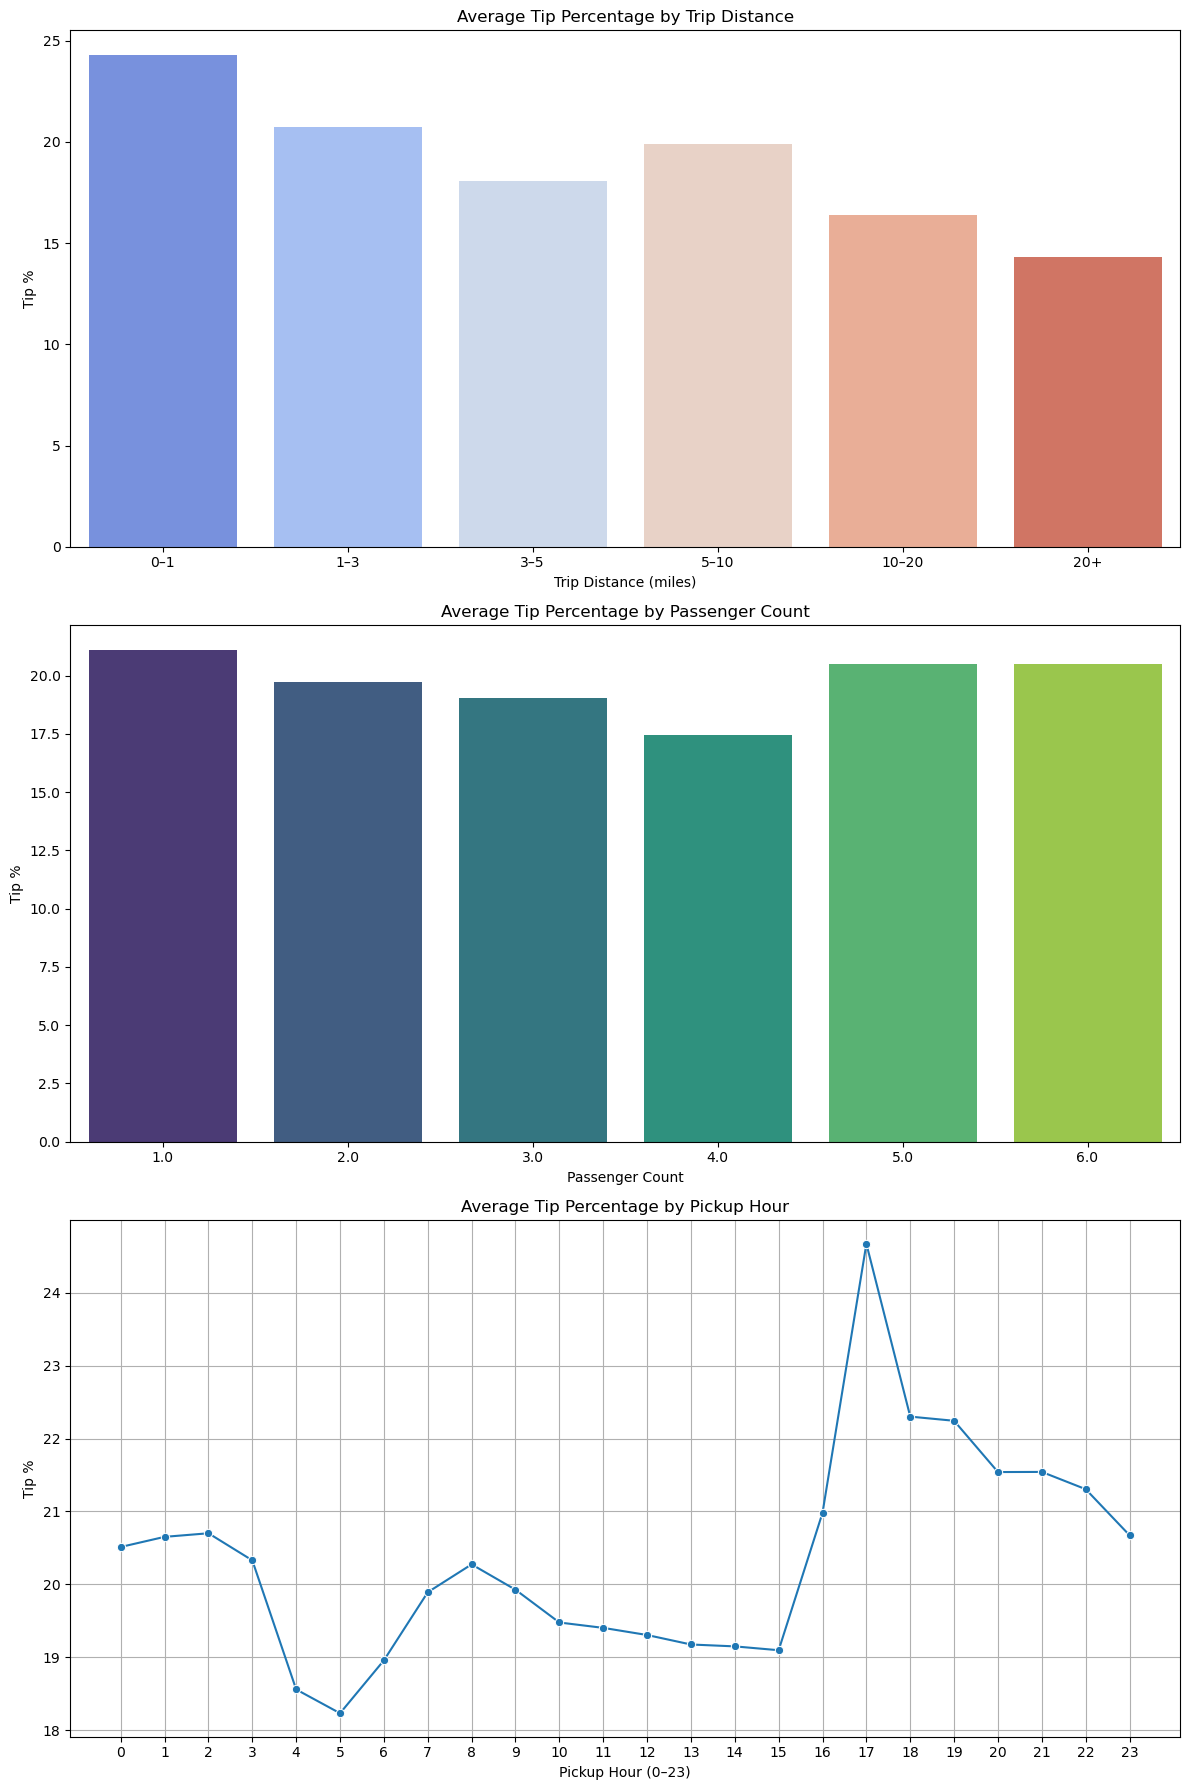

In [459]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1️⃣ Tip % by Trip Distance (use avg_tip_by_distance)
sns.barplot(
    data=avg_tip_by_distance,
    x="distance_tier",
    y="avg_tip_percent",
    palette="coolwarm",
    ax=axes[0]
)
axes[0].set_title("Average Tip Percentage by Trip Distance")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Tip %")

# 2️⃣ Tip % by Passenger Count (use avg_tip_by_passenger)
sns.barplot(
    data=avg_tip_by_passenger,
    x="passenger_count",
    y="avg_tip_percent",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Average Tip Percentage by Passenger Count")
axes[1].set_xlabel("Passenger Count")
axes[1].set_ylabel("Tip %")

# 3️⃣ Tip % by Pickup Hour (use avg_tip_by_hour)
sns.lineplot(
    data=avg_tip_by_hour,
    x="pickup_hour",
    y="avg_tip_percent",
    marker="o",
    ax=axes[2]
)
axes[2].set_title("Average Tip Percentage by Pickup Hour")
axes[2].set_xlabel("Pickup Hour (0–23)")
axes[2].set_ylabel("Tip %")
axes[2].set_xticks(range(0, 24))
axes[2].grid(True)

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [461]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Creating a DF where tip percentage is less than 10 and greater than 25
dfL10G25 = merged_df[(merged_df["tip_percent"] < 10) | (merged_df["tip_percent"] > 25)].copy()

# Create the tier column with only two bins
dfL10G25["tier<10or>25"] = np.where(
    dfL10G25["tip_percent"] <= 10, "<10",  # includes 0–10%
    ">25"                                   # anything above 25%
)

# Now all rows in dfL10G25 have either "<10" or ">25"
dfL10G25.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,Shape_Area,zone,LocationID,borough,geometry,dropoff_hour,fare_per_mile,distance_tier,tip_percent,tier<10or>25
0,VeriFone Inc.,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.86,Standard rate,141,140,Credit card,6.50,...,0.00,Lenox Hill West,141,Manhattan,"POLYGON ((9.95e+05 2.16e+05, 9.95e+05 2.16e+05...",23,7.56,0–1,30.77,>25
1,VeriFone Inc.,2023-01-01 00:07:18,2023-01-01 00:23:15,1.00,7.74,Standard rate,138,256,Cash,32.40,...,0.00,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1.02e+06 2.26e+05, 1.02e+06 2....",0,4.19,5–10,0.00,<10
2,VeriFone Inc.,2023-01-01 00:16:41,2023-01-01 00:21:46,2.00,1.24,Standard rate,161,237,Credit card,7.90,...,0.00,Midtown Center,161,Manhattan,"POLYGON ((9.91e+05 2.14e+05, 9.91e+05 2.14e+05...",0,6.37,1–3,32.66,>25
3,VeriFone Inc.,2023-01-01 00:14:03,2023-01-01 00:24:36,3.00,1.44,Standard rate,237,141,Cash,11.40,...,0.00,Upper East Side South,237,Manhattan,"POLYGON ((9.94e+05 2.17e+05, 9.94e+05 2.17e+05...",0,7.92,1–3,0.00,<10
4,VeriFone Inc.,2023-01-01 00:24:30,2023-01-01 00:29:55,1.00,0.54,Standard rate,143,142,Cash,6.50,...,0.00,Lincoln Square West,143,Manhattan,"POLYGON ((9.89e+05 2.24e+05, 9.89e+05 2.24e+05...",0,12.04,0–1,0.00,<10


C:\Users\shank\AppData\Local\Temp\ipykernel_30032\1492822696.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_distance = dfL10G25.groupby(["tier<10or>25", "distance_tier"]).size().reset_index(name="trip_count")


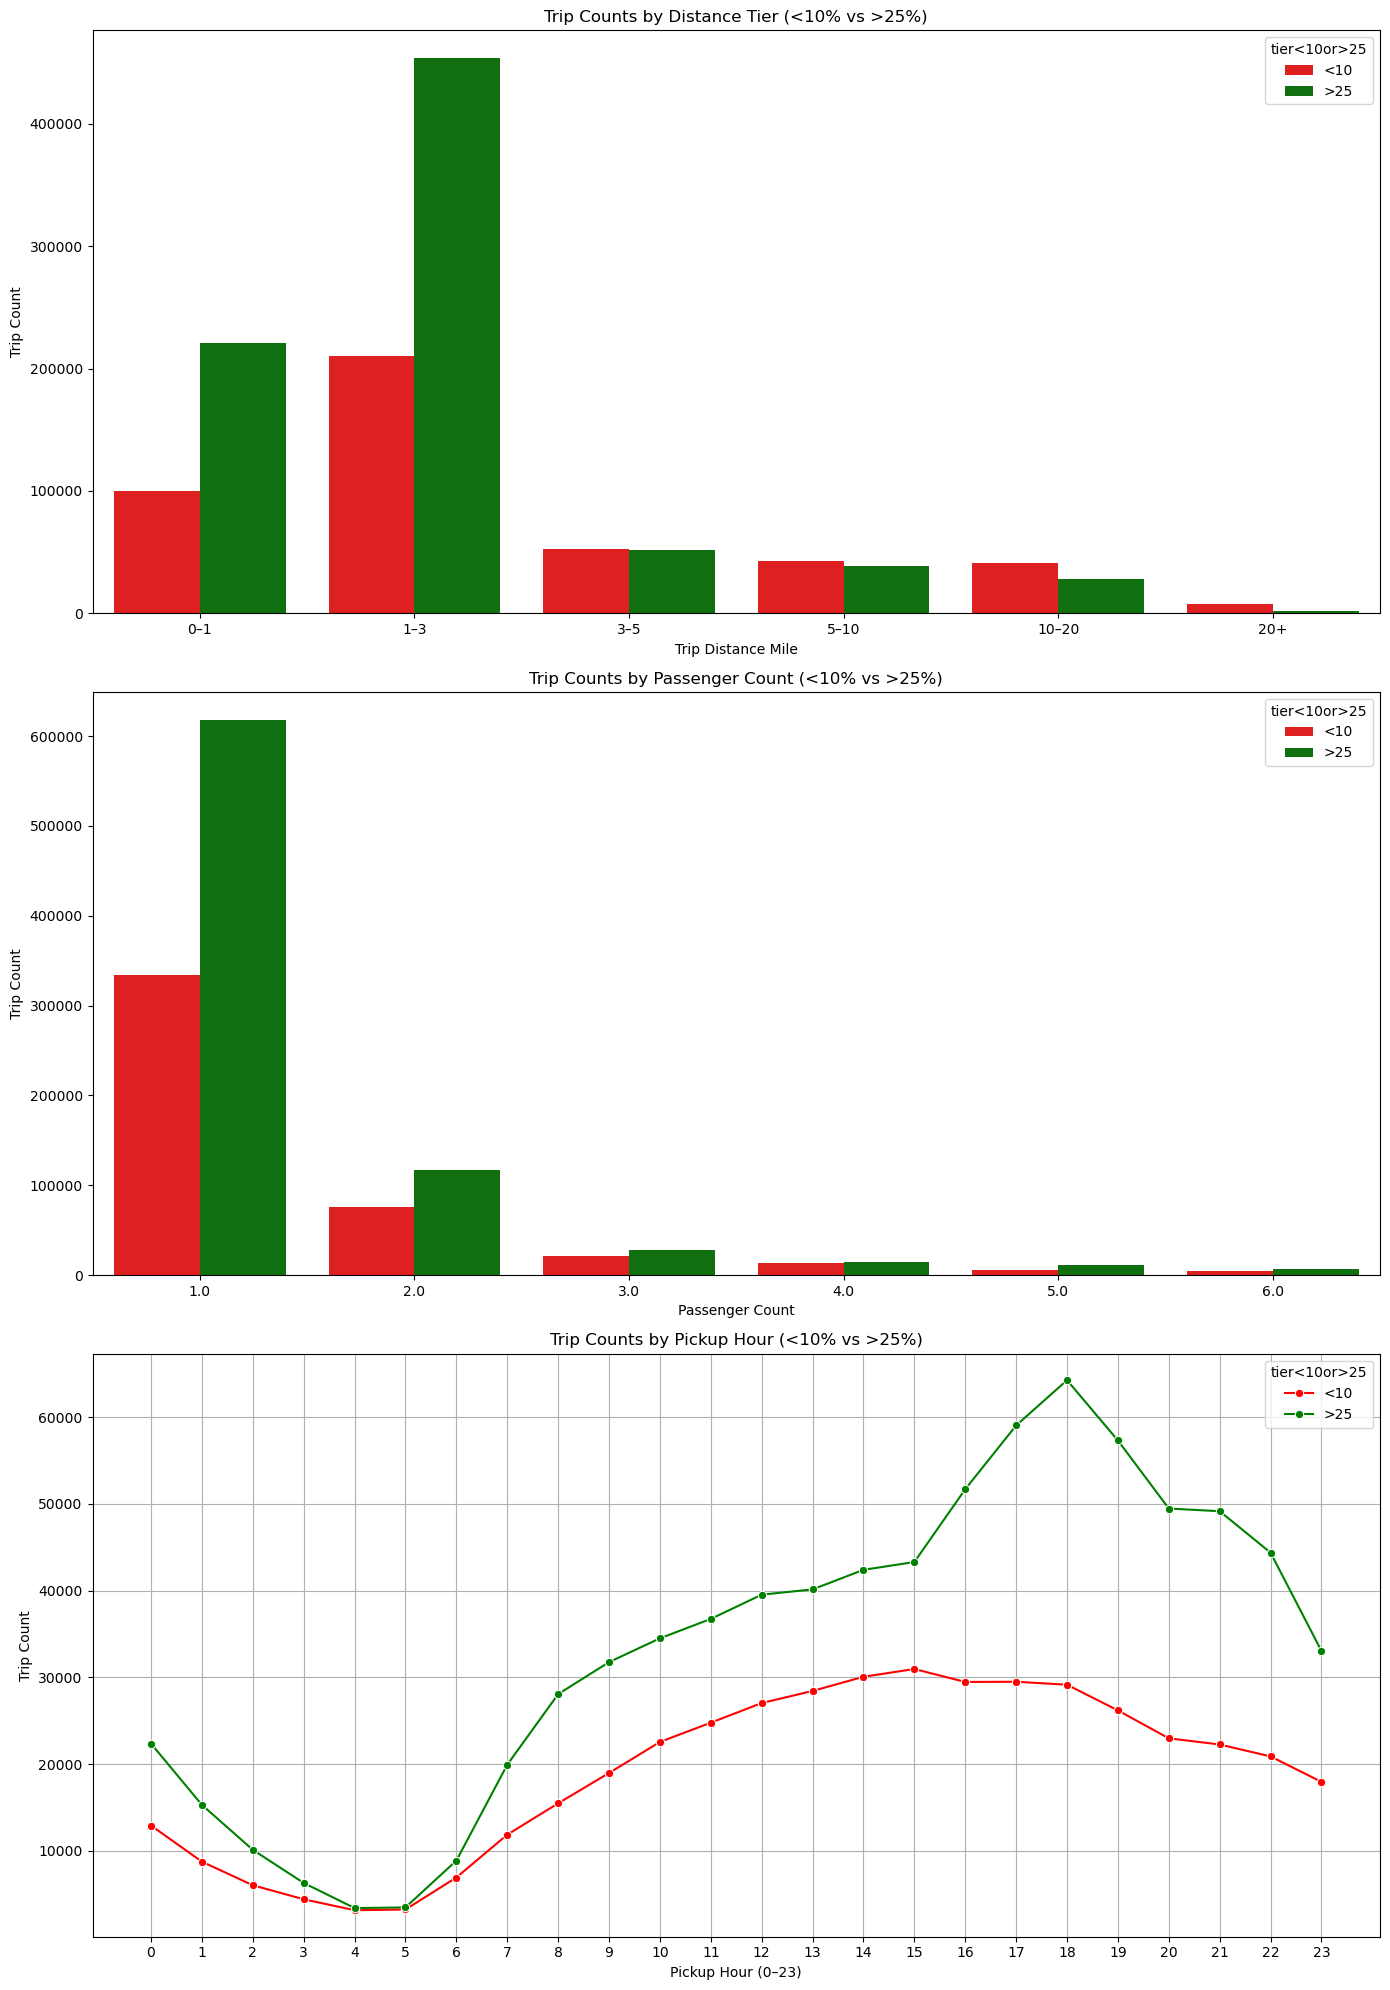

In [462]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ Prepare Data
# -------------------------------
merged_df = merged_df[(merged_df["fare_amount"] > 0) & (merged_df["passenger_count"] > 0)].copy()
merged_df["tip_percent"] = (merged_df["tip_amount"] / merged_df["fare_amount"]) * 100

# Distance tiers
distance_bins = [0, 1, 3, 5, 10, 20, merged_df["trip_distance"].max()]
distance_labels = ["0–1", "1–3", "3–5", "5–10", "10–20", "20+"]
merged_df["distance_tier"] = pd.cut(merged_df["trip_distance"], bins=distance_bins, labels=distance_labels, right=False)

# -------------------------------
# 2️⃣ Filter trips <10% or >25%
# -------------------------------
dfL10G25 = merged_df[(merged_df["tip_percent"] <= 10) | (merged_df["tip_percent"] > 25)].copy()
dfL10G25["tier<10or>25"] = np.where(dfL10G25["tip_percent"] <= 10, "<10", ">25")

# -------------------------------
# 3️⃣ Aggregate trip counts
# -------------------------------
count_by_distance = dfL10G25.groupby(["tier<10or>25", "distance_tier"]).size().reset_index(name="trip_count")
count_by_passenger = dfL10G25.groupby(["tier<10or>25", "passenger_count"]).size().reset_index(name="trip_count")
count_by_hour = dfL10G25.groupby(["tier<10or>25", "pickup_hour"]).size().reset_index(name="trip_count")

# -------------------------------
# 4️⃣ Plot Subplots
# -------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 20))

# 1️⃣ Trip Counts by Distance Tier
sns.barplot(
    data=count_by_distance,
    x="distance_tier",
    y="trip_count",
    hue="tier<10or>25",
    palette=["red", "green"],
    ax=axes[0]
)
axes[0].set_title("Trip Counts by Distance Tier (<10% vs >25%)")
axes[0].set_xlabel("Trip Distance Mile")
axes[0].set_ylabel("Trip Count")

# 2️⃣ Trip Counts by Passenger Count
sns.barplot(
    data=count_by_passenger,
    x="passenger_count",
    y="trip_count",
    hue="tier<10or>25",
    palette=["red", "green"],
    ax=axes[1]
)
axes[1].set_title("Trip Counts by Passenger Count (<10% vs >25%)")
axes[1].set_xlabel("Passenger Count")
axes[1].set_ylabel("Trip Count")

# 3️⃣ Trip Counts by Pickup Hour
sns.lineplot(
    data=count_by_hour,
    x="pickup_hour",
    y="trip_count",
    hue="tier<10or>25",
    marker="o",
    palette=["red", "green"],
    ax=axes[2]
)
axes[2].set_title("Trip Counts by Pickup Hour (<10% vs >25%)")
axes[2].set_xlabel("Pickup Hour (0–23)")
axes[2].set_ylabel("Trip Count")
axes[2].set_xticks(range(0, 24))
axes[2].grid(True)

plt.tight_layout()
plt.show()


## conclusion
1. Distance: For trips up to 3 miles, the tip is above 25% in most cases. For trips longer than 3 miles, the tip percentage tends to be fairly consistent.

2. Passenger Count: When there are fewer than 3 passengers, the tip is generally above 25%. For trips with 3 or more passengers, the tip percentage is relatively uniform.

3. Pickup Time: Tips are mostly greater than 25%, except around the 4th and 5th hours, where they are lower. Tips are significantly higher between 15:00 and 22:00 hours.

**3.2.14** 
Analyse the variation of passenger count across hours and days of the week.

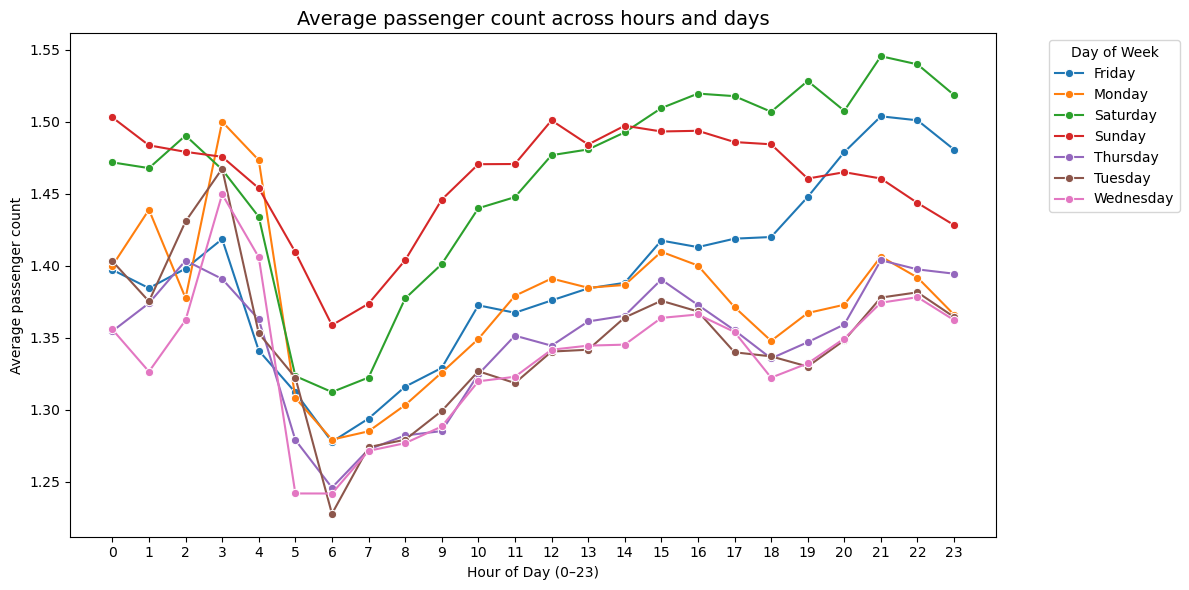

In [465]:
# See how passenger count varies across hours and days

avg_pass = (
    merged_df.groupby(["pickup_day_name","pickup_hour"])
    .agg(
        passenger_count=("passenger_count", "mean"),
        #avg_duration_min=("trip_duration_sec", lambda x: x.mean() / 60),
        #trip_count=("avg_speed", "count")
    )
    .reset_index()
)


plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_pass,
    x="pickup_hour",
    y="passenger_count",
    hue="pickup_day_name",
    marker="o"
)

plt.title("Average passenger count across hours and days", fontsize=14)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average passenger count")
plt.xticks(range(0,24))
plt.legend(title="Day of Week", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [466]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1754056 entries, 0 to 1789917
Data columns (total 34 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               object        
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             object        
 6   PULocationID           int64         
 7   DOLocationID           int64         
 8   payment_type           object        
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  pickup_hour            int32         
 18  airport_fee            floa

# Analysis
1> Early morning (around 4-6 AM), average passenger counts dip to the lowest for every day.
2> Peak periods occur in the late evening hours (around 19-23), especially noticeable on Friday and Saturday when average passenger counts rise sharply.
3> Saturdays have the highest average passenger load during most hours, peaking around late evening, followed by Friday and Sunday 
4> Weekdays like Tuesday, Wednesday, and Thursday show relatively lower passenger counts consistently.
5> The passenger count variation through the day seems to follow typical demand patterns with lower early morning and higher evening activity.
6> Weekends see higher passenger activity overall compared to weekdays.

This analysis suggests busier ride demand on weekends and during late evening hours

**3.2.15** 
Analyse the variation of passenger counts across zones

In [469]:
# How does passenger count vary across zones



In [470]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_passenger_per_zone = merged_df.groupby('zone')['passenger_count'].mean().reset_index()
avg_passenger_per_zone.rename(columns={'passenger_count': 'avg_passenger_count'}, inplace=True)

print(avg_passenger_per_zone.sort_values(by='avg_passenger_count', ascending=False).head(15))

                        zone  avg_passenger_count
164      Ocean Parkway South                 6.00
169               Pelham Bay                 2.50
95                 Gravesend                 2.40
135                  Madison                 2.20
230   West Farms/Bronx River                 2.14
50              Country Club                 2.00
89             Fresh Meadows                 2.00
15                   Belmont                 2.00
13              Bedford Park                 2.00
186            Rockaway Park                 2.00
136          Manhattan Beach                 2.00
96       Green-Wood Cemetery                 2.00
1    Arrochar/Fort Wadsworth                 1.95
180                 Red Hook                 1.91
40        Claremont/Bathgate                 1.89


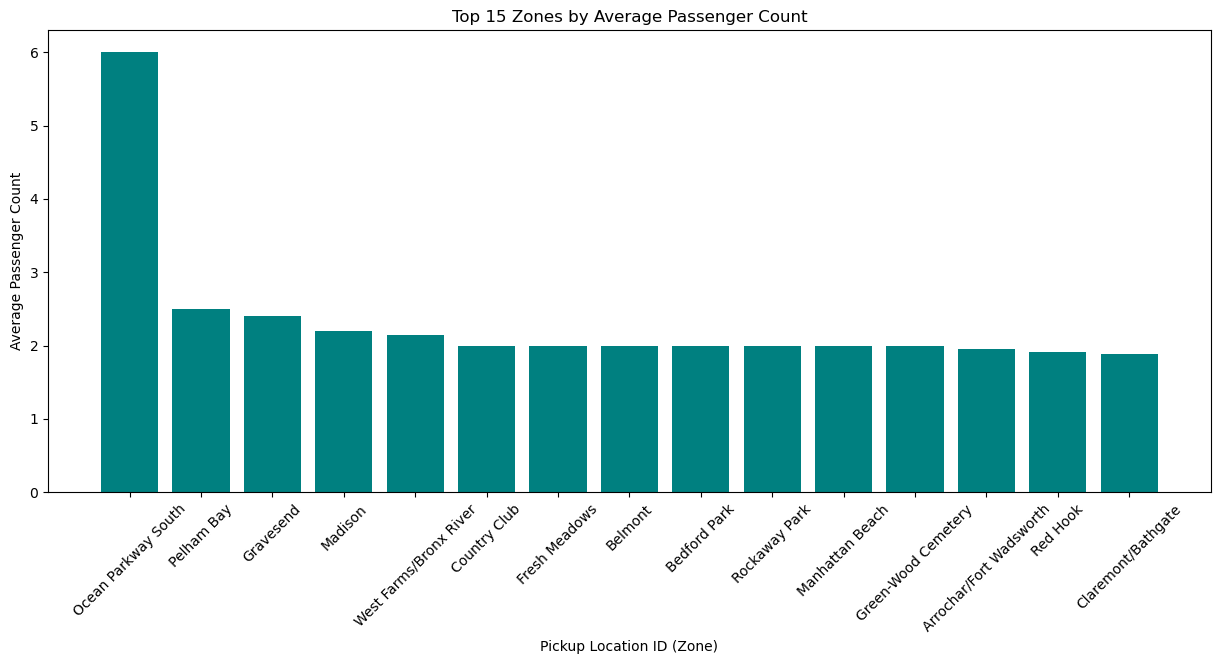

In [471]:
top_zones = avg_passenger_per_zone.sort_values(by='avg_passenger_count', ascending=False).head(15)

plt.figure(figsize=(15, 6))
plt.bar(top_zones['zone'].astype(str), top_zones['avg_passenger_count'], color='teal')
plt.xlabel('Pickup Location ID (Zone)')
plt.ylabel('Average Passenger Count')
plt.title('Top 15 Zones by Average Passenger Count')
plt.xticks(rotation=45)
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** 
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [475]:
# How often is each surcharge applied?

surcharge_cols = ['extra', 'improvement_surcharge', 'congestion_surcharge']

total_trips = len(merged_df)

for col in surcharge_cols:
    count_applied = (merged_df[col] > 0).sum()
    pct_applied = (count_applied / total_trips) * 100
    print(f"{col}: Applied in {count_applied} trips ({pct_applied:.3f}%)")


extra: Applied in 1089826 trips (62.132%)
improvement_surcharge: Applied in 1754021 trips (99.998%)
congestion_surcharge: Applied in 1641088 trips (93.560%)


    PULocationID  extra  improvement_surcharge  congestion_surcharge
0              1   8.51                 100.00                  2.13
1              2   0.00                 100.00                100.00
2              4  83.42                 100.00                 99.71
3              6  54.55                 100.00                  0.00
4              7  48.21                 100.00                 27.91
5              8  50.00                 100.00                 75.00
6              9  16.67                 100.00                  0.00
7             10  37.53                 100.00                 68.65
8             11  66.67                 100.00                 16.67
9             12  41.48                 100.00                 99.75
10            13  58.09                  99.99                 98.88
11            14  71.43                 100.00                 11.43
12            15   0.00                 100.00                  0.00
13            16   0.00           

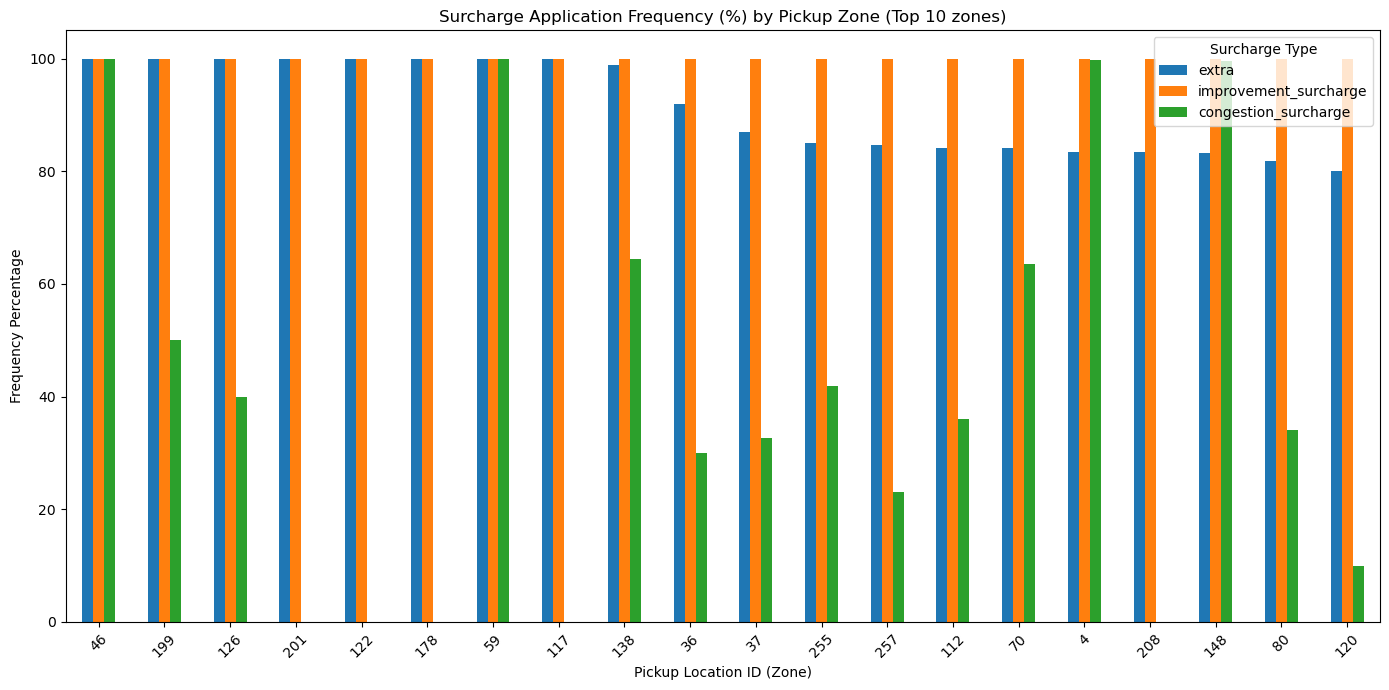

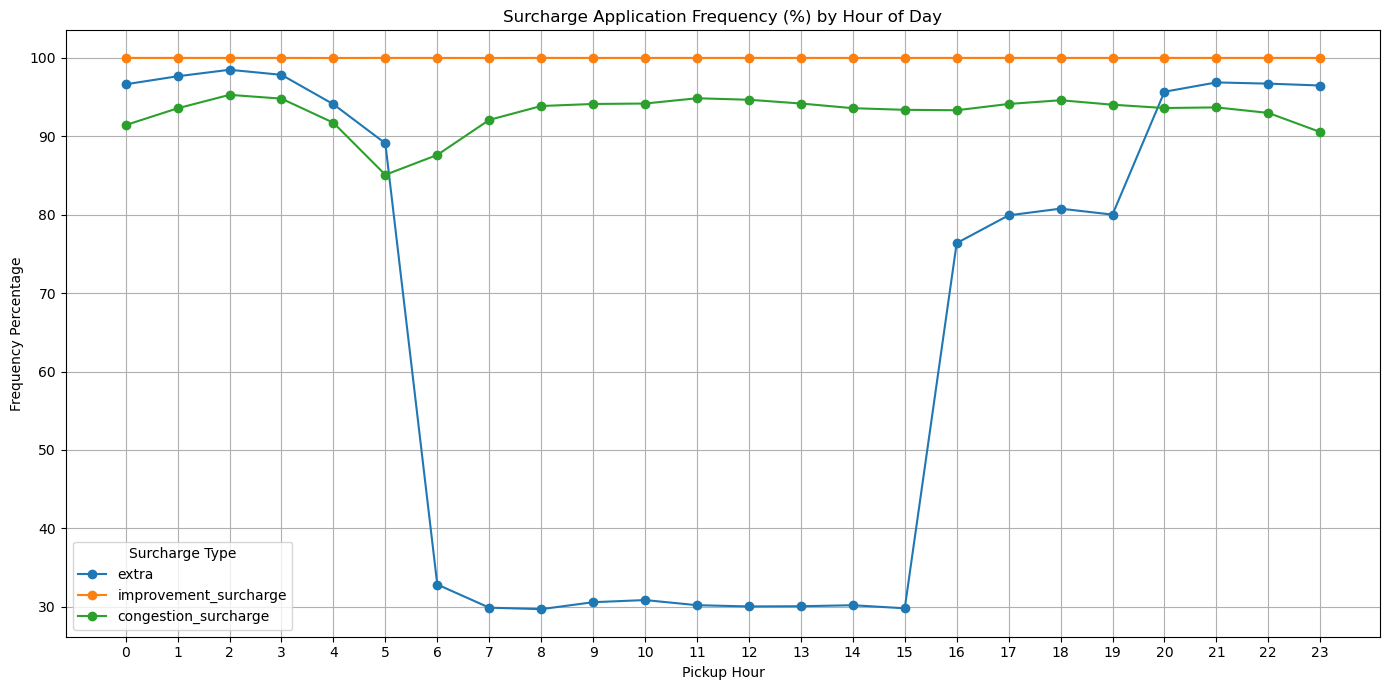

In [476]:
zone_surcharge_freq = merged_df.groupby('PULocationID')[surcharge_cols].apply(lambda x: (x > 0).mean() * 100).reset_index()
print(zone_surcharge_freq.head(20))

hour_surcharge_freq = merged_df.groupby('pickup_hour')[surcharge_cols].apply(lambda x: (x > 0).mean() * 100).reset_index()
print(hour_surcharge_freq.head())

top_zones = zone_surcharge_freq.sort_values('extra', ascending=False).head(20)

top_zones.plot(
    x='PULocationID', 
    y=['extra','improvement_surcharge', 'congestion_surcharge'], 
    kind='bar',
    figsize=(14, 7)
)
plt.title('Surcharge Application Frequency (%) by Pickup Zone (Top 10 zones)')
plt.xlabel('Pickup Location ID (Zone)')
plt.ylabel('Frequency Percentage')
plt.xticks(rotation=45)
plt.legend(title='Surcharge Type')
plt.tight_layout()
plt.show()

hour_surcharge_freq.plot(
    x='pickup_hour', 
    y=['extra', 'improvement_surcharge', 'congestion_surcharge'], 
    kind='line',
    figsize=(14, 7),
    marker='o'
)
plt.title('Surcharge Application Frequency (%) by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Frequency Percentage')
plt.xticks(range(0, 24))
plt.legend(title='Surcharge Type')
plt.grid(True)
plt.tight_layout()
plt.show()


## **4** Conclusion


### **4.1** Final Insights and Recommendations

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** 
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

<p style="font-size:14px; color:#555;">Based on demand patterns and operational inefficiencies</p>

<h3 style="color:#ff7f0e;">Insights:</h3>
<ul style="color:#333; line-height:1.6;">
    <li>Demand is highly time-variant (evening peaks, weekend surges).</li>
    <li>Some zones see <b style="color:#d62728;">“excessive dropoffs but fewer pickups”</b> at certain hours, causing drivers to be stranded far from demand.</li>
    <li>Some zones have a high proportion of short trips, which may reduce profitability after repositioning.</li>
    <li>Idle drivers often cluster suboptimally (too many in low demand zones) while nearby zones may have unmet requests.</li>
</ul>

<h3 style="color:#2ca02c;">Recommendations:</h3>
<ol style="color:#333; line-height:1.6;">
    <li>Increase available drivers (or driver incentives) for evening shifts and weekend shifts; reduce fleet allocation in early morning unless there is a targeted use-case.</li>
    <li>Stage/position drivers near known hotspots at expected peak times (Manhattan cores, airport pickup zones) to reduce pickup wait time and increase driver utilization.</li>
    <li>Create an evidentiary plan for airport pickups (dedicated stands / scheduled rotations) at JFK/EWR to reduce deadhead and increase throughput during peak flight arrival windows.</li>
    <li>A short-term demand forecasts (e.g. next 30–60 min) can be used per zone to direct idle drivers ahead of demand surges, not just respond after requests arrive.</li>
    <li>After a dropoff, if the vehicle is in a low-demand zone, dispatch it (via algorithm) to a nearby zone with predicted excess demand.</li>
    <li>In high-density zones and times with overlapping demand trajectories, consider ride-pooling or merging routes if permitted (i.e., picking up another passenger close along the route with minimal detour).</li>
    <li>Maintain a small reserve fleet (or buffer drivers) that are not fully dispatched, kept ready near emerging demand zones for sudden surges (e.g., weather events).</li>
</ol>


**4.1.2** 

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

# 🚖 Strategic Driver Positioning Guidelines

1. **Build a scheduling plan** where drivers are pre-positioned in high probability pickup zones ~10–20 minutes before the demand peak.  
   *E.g.* at 4:30 pm, send drivers toward the evening surge zones, not wait until the surge starts.

2. **Maintain a target number of idle/active vehicles per hour** for each zone (based on historical pickup density).

3. **Identify intermediate zones** between hotspots and low-demand areas that can act as “staging corridors.”

4. **Use separate positioning heuristics**:  
   - *Weekdays:* business districts & commuting hubs  
   - *Weekends:* entertainment / dining / nightlife corridors and airports

5. **For airports (JFK, LGA)**, maintain a controlled staging queue near terminals so drivers don’t circle or drive long distances waiting.

6. **Keep a fraction of drivers “floating”** (not fixed to one zone) to respond dynamically to surges.

**4.1.3** 
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

# 💸 Dynamic Pricing Strategies for Ride-Hailing Platforms

1. **Adjust fares in real time** based on supply–demand imbalance.  
   *E.g.* If a zone is in high demand and driver supply is low, apply a multiplier (1.2×, 1.5×) on base fare.

2. **Cap the multiplier** to avoid excessively high rates (e.g. max 2×) and maintain rider trust.

3. **Introduce a minimum fare** to ensure profitability for short trips (e.g. all rides < 1 mi have a fixed minimum).

4. **Ramp up surge gradually** (e.g. 1.1× → 1.2× → 1.3×) instead of sudden spikes to reduce rider rejection.

5. **Offer discounts or lower surcharges** during off-peak hours to attract riders.

6. **Incentivize longer trips** with discounted per-mile or per-minute pricing (if the route is profitable).

7. **Loyalty or subscription models** (e.g. flat hourly or daily packages for frequent users) to lock in demand.

8. **Ensure transparency** by clearly showing the base fare, surcharges, and multiplier before ride confirmation.

9. **Share part of the surge pricing** with drivers to motivate them to move toward high-priced zones.

10. **Use pricing incentives** to encourage riders to choose pickup/dropoff in slightly less busy zones, reducing congestion in hotspots.